# CFPB Consumer Complaint Classification, Master Notebook

This project works with real complaint narratives submitted to the Consumer Financial Protection Bureau, a US government agency that collects consumer complaints against banks, lenders, and other financial companies. Each complaint is labeled with one of 5 product categories, checking or savings account, credit card, debt collection, money transfer, or student loan. The goal is to classify each complaint into its correct category based on the text alone.

We started by auditing the raw data for quality issues like duplicates and leakage, then built a simple LSTM model as a baseline. From there we tested a series of improvements, a bidirectional LSTM, dropout, pretrained GloVe word embeddings, a longer input length, and finally a fine-tuned DistilBERT transformer, comparing each one against the baseline to see what actually helped.

All five modular notebooks are combined below in execution order. Each section corresponds to one original notebook file, kept separately in `notebooks/` for reference.

---
# Part: EDA (`01_eda.ipynb`)

# CFPB Consumer Complaint Classification

This project works with real complaint narratives submitted to the Consumer Financial Protection Bureau, a US government agency that collects consumer complaints against banks, lenders, and other financial companies. Each complaint is written in the customer's own words and is labeled with one of 5 product categories, checking or savings account, credit card, debt collection, money transfer, or student loan.

The goal is to automatically classify each complaint into its correct category based on the text alone.

We started by auditing the raw data for quality issues like duplicates and leakage, then built a simple LSTM model as a baseline. From there we tested a series of improvements, a bidirectional LSTM, dropout, pretrained GloVe word embeddings, a longer input length, and finally a fine-tuned DistilBERT transformer, comparing each one against the baseline to see what actually helped.

# Data audit

This is the first step. It checks the raw data before deciding how to split it, clean it, and set up the models. Every cleaning choice below is backed by a number, not a guess.

## Load data

In [1]:
import sys
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")
from src import data, dedup, embeddings, text

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

df = data.load_raw("../data/combined_complaints.parquet")
df.shape

(107992, 16)

In [2]:
pd.DataFrame({"dtype": df.dtypes, "nulls": df.isna().sum(), "nunique": df.nunique()})

,dtype,nulls,nunique
Date received,object,0,107407
Product,object,0,5
Sub-product,object,0,26
Issue,object,0,48
Sub-issue,object,21551,134
Consumer complaint narrative,object,0,101802
Company public response,object,74249,10
Company,object,0,1626
State,object,1318,58
ZIP code,object,263,7176


1. The raw data has 16 columns, but only two matter: the complaint text and the product category. Everything else is dropped before training.
2. Complaint IDs are all unique, so there are no duplicate rows by ID. Whether the same text repeats under different IDs is checked next.

In [3]:
print(df["Consumer complaint narrative"].iloc[0][:400])

Years ago I downloaded an app called Coinbase, but I never subscribed to Coinbase XXXX. In fact, I don't subscribe to anything so I hardly check my transactions because I didn't feel the need to. I noticed XXXX day while checking my transactions that Coinbase XXXX took XXXX dollars from my account. I only noticed this around XXXX of XXXX. I immediately filed a complaint and had a conversation with


In [4]:
df["Product"].value_counts()

Product
Debt collection                                       24007
Checking or savings account                           21547
Money transfer, virtual currency, or money service    21437
Credit card                                           20890
Student loan                                          20111
Name: count, dtype: int64

1. The data has 107,992 rows across 5 product categories.
2. The label text used is the full official CFPB name, not a shortened version.
3. The original label text is kept as is. Shorter names are used only in charts and tables.

## Nulls and blanks

In [5]:
n = data.TEXT_COL
print("null narratives      :", df[n].isna().sum())
print("empty after strip    :", (df[n].str.strip() == "").sum())
print("null labels          :", df[data.LABEL_COL].isna().sum())
print("labels outside the 5 :", (~df[data.LABEL_COL].isin(data.LABELS)).sum())
print("fully duplicated rows:", df.duplicated().sum())

null narratives      : 0
empty after strip    : 0
null labels          : 0
labels outside the 5 : 0


fully duplicated rows: 0


There is no missing text, no blank narratives, no bad label values, and no fully duplicate rows. Nothing needs cleaning here.

## Look at duplicates

In [6]:
dups = data.duplicate_groups(df)
print("rows sharing a narrative :", int(dups.sum()))
print("distinct repeated texts  :", len(dups))
print("rows removed if we keep one of each:", df[n].duplicated().sum())
dups.head(8).rename(lambda t: t[:70]).to_frame("copies")

rows sharing a narrative : 7038
distinct repeated texts  : 848
rows removed if we keep one of each: 6190


,copies
Consumer complaint narrative,
There are collection accounts on my report that I believe contain inac,832
"I am disputing this account as inaccurate and request full validation,",293
"I am disputing this account as inaccurate and request full validation,",238
I am writing to formally request debt validation for a collection acco,224
This debt collector has engaged in conduct that violates the Fair Debt,141
I am writing to formally express my concerns regarding Zelle 's handli,132
I am requesting validation of the alleged debt referenced in your rece,118
I am writing to formally request debt validation for a collection acco,116


In [7]:
# How the repetition is shaped: a few very large templates, a long tail of pairs.
dups.value_counts().sort_index().rename_axis("copies_in_group").to_frame("groups").T

copies_in_group,2,3,4,5,6,7,8,9,10,11,12,13,15,16,17,...,74,80,82,86,89,95,111,116,118,132,141,224,238,293,832
groups,495,119,49,30,19,15,11,7,5,8,4,4,4,5,3,...,2,1,2,2,1,1,1,1,1,1,1,1,1,1,1


In [8]:
dup_rows = df[df[n].duplicated(keep=False)]
pd.DataFrame({
    "duplicate_rows": dup_rows[data.LABEL_COL].value_counts(),
    "share_of_class_%": (100 * dup_rows[data.LABEL_COL].value_counts()
                         / df[data.LABEL_COL].value_counts()).round(1),
})

,duplicate_rows,share_of_class_%
Product,,
Checking or savings account,41,0.2
Credit card,274,1.3
Debt collection,5989,24.9
"Money transfer, virtual currency, or money service",564,2.6
Student loan,170,0.8


1. 7,038 rows repeat text found elsewhere, coming from just 848 distinct texts.
2. Removing repeats drops 6,190 rows.
3. The biggest repeated blocks have 832, 293, and 238 identical submissions. These are template credit repair letters, not a data error.
4. 85% of the repeated rows are Debt collection complaints. After removing duplicates, Debt collection loses 22% of its rows, while Checking or savings loses almost none, only 0.1%.
5. Duplicate text is removed before splitting the data into train and test. Otherwise the same complaint could show up in both, and the model would just memorize it instead of learning.

In [9]:
# Same text filed under different products: an upper bound on achievable accuracy.
spans = dup_rows.groupby(n)[data.LABEL_COL].nunique()
conflict = spans[spans > 1]
print("texts labelled with >1 product:", len(conflict), "| rows involved:",
      int(dup_rows[n].isin(conflict.index).sum()))
(df[df[n].isin(conflict.index)]
   .groupby(df[n].str[:60])[data.LABEL_COL].value_counts()
   .rename("rows").to_frame())

texts labelled with >1 product: 7 | rows involved: 49


rows
Consumer complaint narrative                       Product                          
I am disputing the accuracy of an account being... Credit card                     3
                                                   Debt collection                 1
I am writing to formally dispute my federal stu... Debt collection                 1
                                                   Student loan                    1
I am writing to have the following information ... Credit card                     4
                                                   Checking or savings account     1
                                                   Debt collection                 1
I checked my credit report and noticed some ina... Credit card                     1
                                                   Student loan                    1
I reviewed my consumer credit reports and ident... Debt collection                 4
                                                   Credit card                     1
This debt collector has done unjustifiable prac... Debt collection                26
                                                   Credit card                     1
                                                   Student loan                    1
UNDER THE DOCTRINE OF ESTOPPEL BY SILENCE, XXXX... Debt collection                 1
                                                   Student loan                    1

1. 49 rows, from 7 different texts, are filed under more than one product. These are mostly generic credit report disputes that could reasonably go under either Debt collection or Credit card.
2. That is 0.05% of the data, too small to matter either way.
3. These rows are kept as is instead of being manually relabeled, since there is no clearly correct answer. This also explains part of the Debt collection versus Credit card confusion seen later. It is not really a model mistake.

In [10]:
dd = data.deduplicate(df)
len(dd)

101802

## Near-duplicates

1. Exact match deduplication only catches text that is completely identical. The same template letter with a different name or dollar amount slips right through, and can still leak between train and test.
2. Text similarity was measured using TF-IDF cosine similarity, comparing a large random sample against the full dataset.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

sim_vec = TfidfVectorizer(min_df=3, max_features=60000, sublinear_tf=True,
                          strip_accents="unicode")
A = sim_vec.fit_transform(dd[n])
A.shape

(101802, 21515)

In [12]:
rng = np.random.default_rng(42)
q = np.sort(rng.choice(len(dd), size=6000, replace=False))
best = text.max_similarity(A[q], A, exclude=q)

pd.DataFrame({
    "cosine >=": [0.99, 0.95, 0.90, 0.80, 0.70],
    "docs with a match %": [round(100 * (best >= t).mean(), 2)
                            for t in (0.99, 0.95, 0.90, 0.80, 0.70)],
}).set_index("cosine >=")

,docs with a match %
cosine >=,
0.99,3.28
0.95,6.10
0.90,7.83
0.80,9.62
0.70,10.75


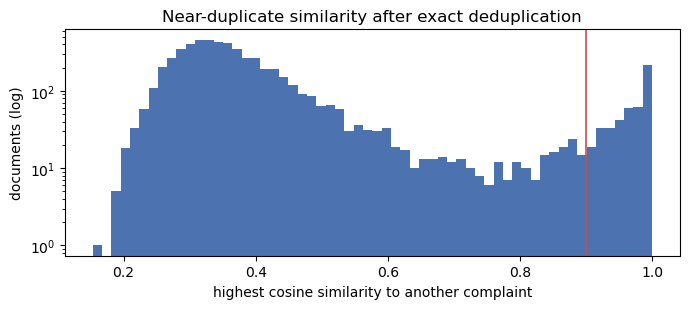

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(best, bins=60, color="#4c72b0")
ax.axvline(0.9, color="#c44e52", lw=1.2)
ax.set_yscale("log")
ax.set_xlabel("highest cosine similarity to another complaint")
ax.set_ylabel("documents (log)")
ax.set_title("Near-duplicate similarity after exact deduplication")
plt.tight_layout()

In [14]:
(pd.DataFrame({"Product": dd[data.LABEL_COL].values[q], "best": best})
   .groupby("Product")["best"].apply(lambda s: round(100 * (s >= 0.9).mean(), 1))
   .rename("near-dup rate % (>=0.90)").to_frame())

,near-dup rate % (>=0.90)
Product,
Checking or savings account,1.7
Credit card,2.1
Debt collection,25.9
"Money transfer, virtual currency, or money service",5.3
Student loan,5.7


1. Even after removing exact duplicates, 7.8% of documents still have a near identical twin, at least 90% similar, somewhere else in the data.
2. Most documents are genuinely unique. The median document's closest match is only 36% similar, but there is a distinct cluster of near copies sitting close to 100% similar.
3. This is heavily concentrated in Debt collection, affecting 25.9% of it, compared to 1.7 to 5.7% in other categories. More template letters.

## Near-duplicate cluster structure

If near-duplicate complaints need to stay together in the same split, train, validation, or test, the clusters of similar documents have to be checked first. Otherwise one giant cluster could distort the whole split.

In [15]:
clusters = dedup.load_clusters("../data/splits/near_dup_clusters.npy", expected_rows=len(dd))
sizes = np.bincount(clusters)
multi = sizes[sizes > 1]

pd.Series({
    "threshold": dedup.CLUSTER_THRESHOLD,
    "clusters": len(sizes),
    "singletons": int((sizes == 1).sum()),
    "multi-row clusters": len(multi),
    "rows inside them": int(multi.sum()),
    "share of corpus %": round(100 * multi.sum() / len(dd), 2),
}).to_frame("value")

,value
threshold,0.70
clusters,93805.00
singletons,91324.00
multi-row clusters,2481.00
rows inside them,10478.00
share of corpus %,10.29


In [16]:
pd.Series({
    "median": int(np.median(multi)),
    "p90": int(np.quantile(multi, 0.90)),
    "p95": int(np.quantile(multi, 0.95)),
    "p99": int(np.quantile(multi, 0.99)),
    "max": int(multi.max()),
}).to_frame("multi-row cluster size")

,multi-row cluster size
median,2
p90,4
p95,6
p99,30
max,696


In [17]:
counts = pd.Series(multi).value_counts().sort_index()
pd.concat([counts.head(6), pd.Series({">10": int((multi > 10).sum())})]).to_frame("clusters")

,clusters
2,1912
3,266
4,97
5,63
6,36
7,19
>10,59


In [18]:
# A cluster spanning several products would push the split off stratification.
per_cluster = pd.DataFrame({"c": clusters, "y": dd[data.LABEL_COL].values})
n_products = per_cluster.groupby("c")["y"].nunique()
mixed = n_products[n_products > 1].index

print("clusters spanning >1 product: %d" % len(mixed))
print("rows involved: %d (%.2f%%)" % (sizes[mixed].sum(), 100 * sizes[mixed].sum() / len(dd)))
print("largest mixed cluster: %d rows" % sizes[mixed].max())
for c in mixed[np.argsort(-sizes[mixed])][:3]:
    print(f"  cluster {c} (n={sizes[c]}):",
          {data.SHORT_LABELS[k]: v for k, v in per_cluster[per_cluster.c == c]["y"].value_counts().items()})

clusters spanning >1 product: 128
rows involved: 1177 (1.16%)
largest mixed cluster: 298 rows
  cluster 2578 (n=298): {'Money transfer': 297, 'Checking/savings': 1}
  cluster 22665 (n=152): {'Debt collection': 150, 'Credit card': 2}
  cluster 29783 (n=129): {'Debt collection': 127, 'Credit card': 2}


1. Most documents, 91,324 of them, have no near duplicate at all.
2. There are 2,481 clusters of similar documents, covering 10.3% of the data. Most are small, with 2 to 6 documents each.
3. The largest cluster has 696 rows, 0.7% of the data. That is sizeable, but not big enough to distort anything.
4. 128 clusters mix two product categories, but each one is overwhelmingly a single label. For example, one cluster has 297 Money transfer complaints against just 1 Checking or savings complaint. These are the same ambiguous dispute letters flagged earlier.
5. It is safe to keep these clusters together within a single split.

## Check the target

In [19]:
summary = data.class_summary(dd[data.LABEL_COL])
summary["raw_n"] = df[data.LABEL_COL].value_counts()
summary["lost_to_dedup_%"] = (100 * (1 - summary["n"] / summary["raw_n"])).round(1)
summary

,n,pct,raw_n,lost_to_dedup_%
Product,,,,
Checking or savings account,21524,21.14,21547,0.1
"Money transfer, virtual currency, or money service",20940,20.57,21437,2.3
Credit card,20684,20.32,20890,1.0
Student loan,19985,19.63,20111,0.6
Debt collection,18669,18.34,24007,22.2


In [20]:
print("largest / smallest :", summary["n"].max(), "/", summary["n"].min())
print("class ratio        : %.3f:1" % (summary["n"].max() / summary["n"].min()))
print("ratio before dedup : %.3f:1" % (df[data.LABEL_COL].value_counts().max()
                                       / df[data.LABEL_COL].value_counts().min()))

largest / smallest : 21524 / 18669
class ratio        : 1.153:1
ratio before dedup : 1.194:1


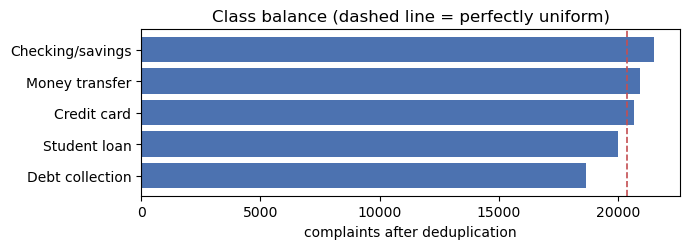

In [21]:
fig, ax = plt.subplots(figsize=(7, 2.6))
s = summary["n"].rename(index=data.SHORT_LABELS).sort_values()
ax.barh(s.index, s.values, color="#4c72b0")
ax.axvline(len(dd) / 5, color="#c44e52", lw=1.2, ls="--")
ax.set_xlabel("complaints after deduplication")
ax.set_title("Class balance (dashed line = perfectly uniform)")
plt.tight_layout()

1. After cleanup there are 101,802 rows, with classes ranging from 18,669 to 21,524 each, about a 1.15 to 1 ratio between the biggest and smallest class.
2. That is a mild imbalance, not a real problem. Every class still has roughly 19,000 training examples.
3. Class weights are not used, since at this ratio weighting would not meaningfully change the results.

## Check text length

In [22]:
words = dd[n].str.split().str.len()
chars = dd[n].str.len()
pd.DataFrame({"words": text.length_summary(words), "characters": text.length_summary(chars)})

,words,characters
min,1.0,6.0
mean,226.5,1352.9
std,214.8,1306.2
p50,178.0,1051.0
p75,288.0,1745.0
p90,436.0,2652.0
p95,570.0,3462.0
p99,1006.0,6077.0
max,5699.0,31995.0


In [23]:
by_class = (dd.assign(w=words).groupby(data.LABEL_COL)["w"]
              .agg(median="median", p75=lambda s: s.quantile(.75),
                   p90=lambda s: s.quantile(.90), mean="mean").round(0))
by_class["trunc@128_%"] = (dd.assign(t=words > 128).groupby(data.LABEL_COL)["t"]
                             .mean().mul(100).round(1))
by_class["trunc@256_%"] = (dd.assign(t=words > 256).groupby(data.LABEL_COL)["t"]
                             .mean().mul(100).round(1))
by_class.rename(index=data.SHORT_LABELS)

,median,p75,p90,mean,trunc@128_%,trunc@256_%
Product,,,,,,
Checking/savings,189.0,301.0,454.0,238.0,68.1,33.3
Credit card,207.0,319.0,470.0,252.0,72.2,37.0
Debt collection,155.0,264.0,395.0,202.0,60.3,26.3
Money transfer,167.0,269.0,402.0,214.0,62.5,27.2
Student loan,171.0,285.0,443.0,224.0,62.3,29.5


In [24]:
text.truncation_table(words, [64, 128, 192, 256, 384, 512])

,truncated_%,tokens_kept_%
max_len,,
64,86.1,26.7
128,65.2,48.1
192,46.1,63.8
256,30.8,74.6
384,13.5,86.5
512,6.6,91.9


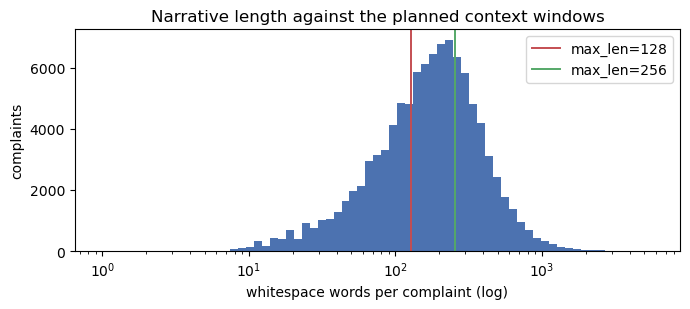

In [25]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(words, bins=np.logspace(0, np.log10(words.max()), 70), color="#4c72b0")
for m, c in [(128, "#c44e52"), (256, "#55a868")]:
    ax.axvline(m, color=c, lw=1.4, label=f"max_len={m}")
ax.set_xscale("log")
ax.set_xlabel("whitespace words per complaint (log)")
ax.set_ylabel("complaints")
ax.set_title("Narrative length against the planned context windows")
ax.legend()
plt.tight_layout()

1. A typical complaint is 178 words, but some run much longer. The 90th percentile is 436 words, and the longest is 5,699.
2. Cutting text at 128 words means the model only reads 48% of all the text overall. Extending to 256 words keeps 75%.
3. Longer complaints, like Credit card at a median of 207 words, get cut more than shorter ones, like Debt collection at 155 words. Truncation does not hit every category equally.
4. 203 complaints are under 10 words. They are still valid complaints and are kept as is.
5. The earlier models use a 128 word limit and the more advanced one uses 256. This matches the original plan and gives a fair before and after comparison of what extra context buys.

## Text quality

In [26]:
text.artifact_counts(dd[n])

,docs,pct
artifact,,
XXXX redaction,88331,86.77
XX/XX date,53154,52.21
year> placeholder,28036,27.54
{$...} amount,45747,44.94
bytes repr wrapper,673,0.66
url,178,0.17
email,14,0.01
html tag,8,0.01
non-ascii,0,0.00


In [27]:
# The `b'...'` rows are a byte-string repr that survived into the extract.
wrapped = dd[n].str.startswith("b'") | dd[n].str.startswith('b"')
print("rows:", int(wrapped.sum()), "| %.2f%%" % (100 * wrapped.mean()))
print(dd.loc[wrapped, data.LABEL_COL].value_counts().to_dict())
print()
print("raw     :", dd.loc[wrapped, n].iloc[1][:150])
print("unwrapped:", text.strip_bytes_wrapper(dd.loc[wrapped, n].iloc[1])[:150])

rows: 673 | 0.66%
{'Money transfer, virtual currency, or money service': 191, 'Credit card': 173, 'Checking or savings account': 140, 'Debt collection': 128, 'Student loan': 41}

raw     : b"Sofi, after XXXX  dispute XXXX XXXX appeals, XXXX  a police scam report, a identity theft affidavit, a court bank records subpoena, as scam criminal
unwrapped: Sofi, after XXXX  dispute XXXX XXXX appeals, XXXX  a police scam report, a identity theft affidavit, a court bank records subpoena, as scam criminal i


In [28]:
top_share = dd[n].str.split().apply(lambda t: Counter(t).most_common(1)[0][1] / len(t))
upper = dd[n].str.count(r"[A-Z]") / dd[n].str.len()
digits = dd[n].str.count(r"\d") / dd[n].str.len()
pd.Series({
    "one token is >30% of the doc": int((top_share > 0.30).sum()),
    "over 60% uppercase chars": int((upper > 0.60).sum()),
    "over 20% digit chars": int((digits > 0.20).sum()),
    "under 10 words": int((words < 10).sum()),
    "over 1000 words": int((words > 1000).sum()),
}).to_frame("documents")

,documents
one token is >30% of the doc,364
over 60% uppercase chars,415
over 20% digit chars,6
under 10 words,203
over 1000 words,1032


1. There is almost no junk text. URLs, emails, HTML tags, and non-English characters each make up under 0.2% of the data.
2. Some formatting quirks are actually meaningful, not noise. Half the complaints have blank lines, and 415 are mostly in all caps, which is people venting, a real tone signal.
3. 673 rows, 0.66% of the data, have a text encoding glitch, wrapped in stray byte formatting. This shows up equally across all five categories, so it is just noise, not tied to any one class.
4. The encoding glitch is fixed on those 673 rows. Everything else, capitalization, punctuation, repetition, is left untouched, since that is just how people write, and the tokenizer handles casing anyway.

## Inspect redactions

CFPB blanks out names, dates, and amounts before publishing complaints. If one category had noticeably more of these blanked out placeholders than others, a model could learn to guess the category from that pattern instead of the actual complaint. That kind of shortcut would not work on real, unredacted text.

In [29]:
x_count = text.count_matches(dd[n], r"\bX{2,}\b")
print("complaints containing XXXX: %d (%.1f%%)" % ((x_count > 0).sum(),
                                                   100 * (x_count > 0).mean()))
text.length_summary(x_count).to_frame("XXXX per complaint")

complaints containing XXXX: 88331 (86.8%)


,XXXX per complaint
min,0.0
mean,13.8
std,28.5
p50,7.0
p75,17.0
p90,32.0
p95,46.0
p99,100.0
max,4306.0


In [30]:
red = dd.assign(x=x_count, w=words, dens=100 * x_count / words)
pd.DataFrame({
    "has XXXX %": red.groupby(data.LABEL_COL)["x"].apply(lambda s: 100 * (s > 0).mean()).round(1),
    "mean count": red.groupby(data.LABEL_COL)["x"].mean().round(1),
    "median count": red.groupby(data.LABEL_COL)["x"].median(),
    "median density %": red.groupby(data.LABEL_COL)["dens"].median().round(2),
}).rename(index=data.SHORT_LABELS)

,has XXXX %,mean count,median count,median density %
Product,,,,
Checking/savings,88.9,14.1,8.0,4.29
Credit card,89.6,15.2,9.0,4.53
Debt collection,81.6,11.8,6.0,4.03
Money transfer,86.2,13.2,7.0,4.48
Student loan,86.9,14.6,7.0,4.80


In [31]:
for label in ["Credit card", "Debt collection"]:
    row = dd[dd[data.LABEL_COL] == label].iloc[3]
    print(f"--- {label} ---")
    print(row[n][:260], "\n")

--- Credit card ---
I was approached by a XXXX store associate who offered me a rewards card. I was not informed that this was a credit card or that signing up would result in a hard inquiry on my credit report. I believed I was signing up for a simple rewards/loyalty program, no 

--- Debt collection ---
I'm not sure why! We change our insurance company when our policy window came to an end. We were told by XXXX XXXX ; they would drop us if we didn't pay. We were looking for another company at the time to lower our rates, which started to get out of hand. When 



1. 86.8% of complaints contain the redaction placeholder XXXX, averaging about 14 per complaint.
2. The rate is fairly even across categories, roughly 4 to 5% of all words regardless of product. Once complaint length is accounted for, there is no real gap between categories.
3. The placeholder text is kept in. It is one of the most common words in the dataset, and removing it would erase useful signal about where a name or amount was mentioned. Both model types handle it fine as a token.

## Vocabulary

In [32]:
seqs = [text.keras_word_sequence(t) for t in dd[n]]
vocab = Counter()
for s in seqs:
    vocab.update(s)
total = sum(vocab.values())
print("vocabulary size :", len(vocab))
print("total tokens    :", total)
print("hapax           : %d (%.0f%% of types)" % (sum(1 for c in vocab.values() if c == 1),
                                                  100 * sum(1 for c in vocab.values() if c == 1) / len(vocab)))
pd.DataFrame([{"max_features": k,
               "corpus tokens covered %": round(100 * sum(c for _, c in vocab.most_common(k)) / total, 2)}
              for k in (5000, 10000, 20000, 30000, 50000)]).set_index("max_features")

vocabulary size : 57396
total tokens    : 23174386
hapax           : 27351 (48% of types)


,corpus tokens covered %
max_features,
5000,98.05
10000,99.36
20000,99.78
30000,99.88
50000,99.97


In [33]:
pd.Series(dict(vocab.most_common(15))).to_frame("count")

,count
xxxx,1057854
the,981365
i,734410
to,707881
and,653709
my,471067
a,450863
of,412261
xx,324831
that,317534


In [34]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(min_df=20, max_features=30000)
counts = cv.fit_transform(dd[n])
terms = cv.get_feature_names_out()

distinctive = {
    data.SHORT_LABELS[label]: text.top_terms_by_log_odds(
        counts, terms, (dd[data.LABEL_COL] == label).values, k=12)
    for label in data.LABELS
}
pd.DataFrame(distinctive)

,Checking/savings,Credit card,Debt collection,Money transfer,Student loan
0,webster,jetblue,1618d,abound,edfinancial
1,chexsystems,elan,credence,kraken,pslf
2,cd,citicard,waypoint,offenders,mohelas
3,marcus,comenitys,aldous,moneygram,ibr
4,etrade,lowe,procollect,abra,mohela
5,novo,barclay,sequium,unfeasible,idr
6,hsa,carecredit,tsi,infeasible,studentaid
7,axos,aadvantage,fco,remitlys,navient
8,229,kohls,ncs,eth,nelnet
9,matured,citicards,jefferson,krakens,ferpa


In [35]:
# How much vocabulary the classes actually share.
top_sets = {}
for label in data.LABELS:
    c = np.asarray(counts[(dd[data.LABEL_COL] == label).values].sum(0)).ravel()
    top_sets[data.SHORT_LABELS[label]] = set(terms[np.argsort(-c)[:2000]])
names = list(top_sets)
pd.DataFrame([[round(len(top_sets[a] & top_sets[b]) / len(top_sets[a] | top_sets[b]), 2)
               for b in names] for a in names], index=names, columns=names)

,Checking/savings,Credit card,Debt collection,Money transfer,Student loan
Checking/savings,1.00,0.74,0.58,0.79,0.60
Credit card,0.74,1.00,0.62,0.68,0.62
Debt collection,0.58,0.62,1.00,0.56,0.58
Money transfer,0.79,0.68,0.56,1.00,0.57
Student loan,0.60,0.62,0.58,0.57,1.00


1. There are 57,396 unique words in total, but almost half of them, 48%, only appear once. That is a very long tail of rare words.
2. The most common 20,000 words already cover 99.78% of all the text, so a bigger vocabulary barely helps.
3. The words that actually separate categories are brand and servicer names, for example mohela, navient, and pslf for Student loan, coinbase, zelle, and binance for Money transfer, and fdcpa for Debt collection. Categories share most of their common vocabulary and differ mainly on these specific terms.
4. The vocabulary is capped at 20,000 words. Anything rarer is mapped to a generic unknown word token instead of being dropped.

## Check leakage

There are two different things worth telling apart here. One is a model finding a shortcut unrelated to the actual complaint, which is a real problem. The other is the task just being genuinely easy because people describe their product directly, which is fine and expected.

In [36]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# Can the label be predicted from redaction and formatting counts alone,
# with every word thrown away?
probe = pd.DataFrame({
    "xxxx": x_count.values,
    "amounts": dd[n].str.count(r"\{\$[\d.,]+\}").values,
    "dates": dd[n].str.count(r"XX/XX/").values,
    "words": words.values,
})
probe["xxxx_density"] = probe.xxxx / probe.words
y = dd[data.LABEL_COL].values
ptr, pte, ytr, yte = train_test_split(probe, y, test_size=0.2, random_state=42, stratify=y)

for name, cols in [("redaction only", ["xxxx", "amounts", "dates", "xxxx_density"]),
                   ("length only", ["words"]),
                   ("redaction + length", list(probe.columns))]:
    m = HistGradientBoostingClassifier(max_iter=150, random_state=42).fit(ptr[cols], ytr)
    print("%-20s macro-F1 %.3f" % (name, f1_score(yte, m.predict(pte[cols]), average="macro")))
print("%-20s macro-F1 %.3f" % ("random guess", 0.200))

redaction only       macro-F1 0.274


length only          macro-F1 0.228


redaction + length   macro-F1 0.286
random guess         macro-F1 0.200


1. Using only redaction counts, with no actual complaint text, to guess the category gets 0.274 accuracy, barely better than the 0.200 you would get by guessing randomly.
2. Using the real complaint text gets 0.86. Redactions carry a tiny bit of signal, but nowhere near enough to be a shortcut.

In [37]:
# Do complaints name their own product?
cues = {
    "Checking or savings account": r"checking account|savings account|overdraft",
    "Credit card": r"credit card",
    "Debt collection": r"debt collector|collection agency|fdcpa",
    "Money transfer, virtual currency, or money service": r"zelle|venmo|paypal|cash app|crypto|wire transfer",
    "Student loan": r"student loan|navient|mohela|nelnet",
}
low = dd[n].str.lower()
rows = []
for label, pattern in cues.items():
    hit = low.str.contains(pattern, regex=True)
    inside = (dd[data.LABEL_COL] == label).values
    rows.append({"class": data.SHORT_LABELS[label],
                 "cue in class %": round(100 * hit[inside].mean(), 1),
                 "cue elsewhere %": round(100 * hit[~inside].mean(), 1)})
pd.DataFrame(rows).set_index("class")

,cue in class %,cue elsewhere %
class,,
Checking/savings,27.6,3.2
Credit card,47.5,3.3
Debt collection,40.2,1.0
Money transfer,49.2,3.1
Student loan,70.9,0.2


People often name their product directly in the complaint, 28 to 71% of the time depending on category, and rarely mention other products, under 3.3%. That is realistic. It is what a real classifier would rely on too, not a sign of a flawed dataset.

## TF-IDF reference

This is just a quick reference check, not one of the actual models being compared. It uses a temporary data split for measurement only. The real train and test split is built in the next stage.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

idx_tr, idx_te = train_test_split(np.arange(len(dd)), test_size=0.10,
                                  random_state=42, stratify=y)
vec = TfidfVectorizer(min_df=3, max_features=60000, sublinear_tf=True,
                      strip_accents="unicode")
Xtr = vec.fit_transform(dd[n].iloc[idx_tr])
Xte = vec.transform(dd[n].iloc[idx_te])
clf = LogisticRegression(max_iter=400, C=4.0).fit(Xtr, y[idx_tr])
pred = clf.predict(Xte)
print(classification_report(y[idx_te], pred, digits=3))

                                                    precision    recall  f1-score   support

                       Checking or savings account      0.756     0.790     0.772      2153
                                       Credit card      0.861     0.845     0.853      2068
                                   Debt collection      0.913     0.924     0.918      1867
Money transfer, virtual currency, or money service      0.820     0.799     0.809      2094
                                      Student loan      0.972     0.958     0.965      1999

                                          accuracy                          0.860     10181
                                         macro avg      0.864     0.863     0.863     10181
                                      weighted avg      0.861     0.860     0.861     10181



In [39]:
pd.DataFrame(confusion_matrix(y[idx_te], pred, labels=data.LABELS),
             index=[data.SHORT_LABELS[l] for l in data.LABELS],
             columns=[data.SHORT_LABELS[l] for l in data.LABELS])

,Checking/savings,Credit card,Debt collection,Money transfer,Student loan
Checking/savings,1700,139,18,291,5
Credit card,157,1747,91,62,11
Debt collection,21,80,1725,11,30
Money transfer,360,46,6,1673,9
Student loan,12,18,50,4,1915


1. A basic bag of words model already gets 0.863 Macro F1, pretty strong for something this simple.
2. The easiest category is Student loan at 0.965 F1. The hardest is Checking or savings at 0.772 F1.
3. The main confusion is between Checking or savings and Money transfer, which makes sense since both are account level payment issues.
4. This is just a reference point, not a target the real models need to beat.

In [40]:
# How much of that 0.864 is near-duplicate contamination?
best_te = text.max_similarity(A[idx_te], A[idx_tr], exclude=None)
rows = []
for thr in (0.95, 0.90, 0.80):
    hit = best_te >= thr
    rows.append({
        "threshold": thr,
        "test docs with a train near-dup": int(hit.sum()),
        "%": round(100 * hit.mean(), 2),
        "macro-F1 on those": round(f1_score(y[idx_te][hit], pred[hit], average="macro"), 3),
        "macro-F1 on the rest": round(f1_score(y[idx_te][~hit], pred[~hit], average="macro"), 3),
    })
pd.DataFrame(rows).set_index("threshold")

,test docs with a train near-dup,%,macro-F1 on those,macro-F1 on the rest
threshold,,,,
0.95,541,5.31,0.924,0.859
0.90,724,7.11,0.922,0.858
0.80,890,8.74,0.889,0.858


In [41]:
# Which classes the contaminated test documents belong to.
(pd.Series(y[idx_te][best_te >= 0.90]).value_counts()
   .rename(index=data.SHORT_LABELS).rename("contaminated test docs").to_frame())

,contaminated test docs
Debt collection,412
Student loan,118
Money transfer,116
Credit card,53
Checking/savings,25


1. 7.1% of the test set has a near identical twin sitting in the training set, meaning the model has basically already seen it.
2. On those documents the model scores 0.922, compared to 0.858 on everything else. That gap inflates the overall score by roughly 0.45 points.
3. 57% of this overlap is Debt collection complaints, so that category's score is the most affected.
4. The train, validation, and test split needs to keep near-duplicate groups together in one split instead of scattering them across all three. Exact duplicate removal alone is not enough. This does not change the dataset size, the split ratios, or which models get tested, just how the split is built.

## Token lengths

Word counts so far were just whitespace split words, which is not actually what either model sees. The LSTM tokenizer splits differently, and the transformer tokenizer breaks unfamiliar words, like jargon and redaction markers, into smaller sub-word pieces. Real sequence lengths need to be measured separately for each tokenizer.

In [42]:
from transformers import AutoTokenizer

keras_len = np.array([len(s) for s in seqs])
wp_tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
wp_len = text.wordpiece_lengths(dd[n], wp_tok)

pd.DataFrame({
    "whitespace": text.length_summary(words),
    "keras": text.length_summary(keras_len),
    "distilbert wordpiece": text.length_summary(wp_len),
})

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1015 > 512). Running this sequence through the model will result in indexing errors


,whitespace,keras,distilbert wordpiece
min,1.0,1.0,5.0
mean,226.5,227.6,292.0
std,214.8,214.7,286.1
p50,178.0,180.0,228.0
p75,288.0,290.0,369.0
p90,436.0,438.0,563.0
p95,570.0,569.0,736.0
p99,1006.0,1008.0,1317.0
max,5699.0,5830.0,9071.0


In [43]:
print(wp_tok.tokenize("XXXX XX/XX/2024 {$1500.00} ACH chargeback overdraft Navient forbearance"))
print("wordpiece / keras length ratio: median %.2f, p90 %.2f"
      % (np.median(wp_len / keras_len), np.quantile(wp_len / keras_len, 0.9)))

['xx', '##xx', 'xx', '/', 'xx', '/', '202', '##4', '{', '$', '1500', '.', '00', '}', 'ac', '##h', 'charge', '##back', 'over', '##dra', '##ft', 'na', '##vie', '##nt', 'for', '##be', '##aran', '##ce']
wordpiece / keras length ratio: median 1.26, p90 1.42


In [44]:
pd.concat({"keras": text.truncation_table(keras_len, [128, 256, 512]),
           "distilbert": text.truncation_table(wp_len, [128, 256, 512])}, axis=0)

truncated_%  tokens_kept_%
           max_len                            
keras      128             65.6           48.0
           256             31.0           74.6
           512              6.6           91.9
distilbert 128             74.4           39.2
           256             43.9           64.9
           512             12.5           86.8

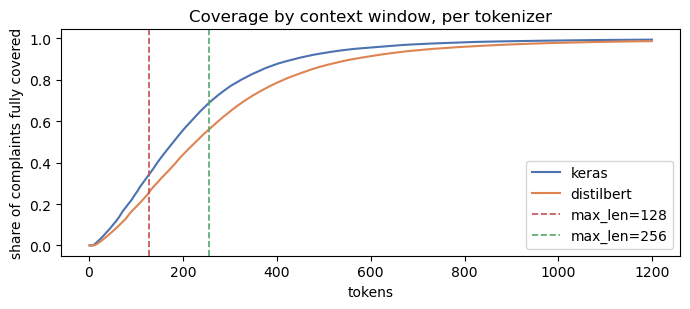

In [45]:
fig, ax = plt.subplots(figsize=(7, 3.2))
grid = np.arange(1, 1200)
for name, L, colour in [("keras", keras_len, "#4c72b0"), ("distilbert", wp_len, "#dd8452")]:
    ax.plot(grid, np.searchsorted(np.sort(L), grid, side="right") / len(L),
            label=name, color=colour)
for m, c in [(128, "#c44e52"), (256, "#55a868")]:
    ax.axvline(m, color=c, lw=1.2, ls="--", label=f"max_len={m}")
ax.set_xlabel("tokens")
ax.set_ylabel("share of complaints fully covered")
ax.set_title("Coverage by context window, per tokenizer")
ax.legend()
plt.tight_layout()

1. The transformer tokenizer breaks words into more pieces than the LSTM tokenizer does, about 26% more tokens per complaint on average. The median length is 178 for LSTM and 228 for the transformer.
2. This means that at the same length cutoff, the transformer actually sees less of each complaint. At a 256 token limit, the LSTM keeps about 69% of a typical complaint while the transformer keeps only 56%.
3. This happens because financial terms and redaction placeholders get chopped into sub-pieces. For example, navient becomes na, vie, and nt.
4. The same length limit is kept across models for a fair comparison, but the transformer is technically working with less context per complaint. If it still wins despite that handicap, the result is more convincing. If it loses narrowly, this is the first thing to check.

## GloVe coverage

One experiment swaps in pre-trained GloVe word vectors instead of starting from random ones. That is only a fair test if GloVe actually covers this dataset's vocabulary, checked below.

In [46]:
glove = embeddings.load_glove_vocab("../data/embeddings/glove.6B.100d.txt")
print("glove vocabulary:", len(glove))
embeddings.coverage(vocab, glove, [1000, 5000, 10000, 20000, 30000, None])

glove vocabulary: 400001


,types_in_glove_%,tokens_in_glove_%,corpus_covered_%
vocab_size,,,
1000,98.6,99.60,86.31
5000,97.2,99.32,97.39
10000,94.1,99.23,98.60
20000,86.5,99.16,98.94
30000,76.3,99.11,99.00
57396,53.0,99.03,99.03


In [47]:
pd.DataFrame(embeddings.missing_terms(vocab, glove, 20000, k=24),
             columns=["term", "corpus count"]).set_index("term")

,corpus count
term,
mohela,20791
fdcpa,8272
navient,6349
didn't,5575
i'm,5074
don't,4963
pslf,4338
i've,4180
coinbase,4102


In [48]:
# Coverage on the terms that actually separate the classes.
pd.DataFrame([
    {"class": short,
     "distinctive terms in glove": f"{sum(1 for t in terms_ if t in glove)}/{len(terms_)}"}
    for short, terms_ in {
        data.SHORT_LABELS[label]: text.top_terms_by_log_odds(
            counts, terms, (dd[data.LABEL_COL] == label).values, k=30)
        for label in data.LABELS}.items()
]).set_index("class")

,distinctive terms in glove
class,
Checking/savings,26/30
Credit card,21/30
Debt collection,23/30
Money transfer,15/30
Student loan,18/30


In [49]:
# Contractions miss because the Keras filter keeps the apostrophe and GloVe's
# tokenizer splits on it. Worth deviating from the default filters?
split_apostrophes = Counter()
for word, c in vocab.items():
    for part in (word.split("'") if "'" in word else [word]):
        if part:
            split_apostrophes[part] += c
pd.concat({"keras defaults": embeddings.coverage(vocab, glove, [20000]),
           "apostrophe stripped": embeddings.coverage(split_apostrophes, glove, [20000])})

,,types_in_glove_%,tokens_in_glove_%,corpus_covered_%
,vocab_size,,,
keras defaults,20000,86.5,99.16,98.94
apostrophe stripped,20000,87.4,99.35,99.14


1. GloVe covers 99.16% of all word occurrences in the dataset. That looks great, but the number is misleading.
2. The words GloVe is missing are not random junk. They are exactly the words that matter most for telling categories apart, brand and servicer names like mohela, navient, coinbase, and fdcpa.
3. For Money transfer and Student loan, GloVe only has vectors for about half of the most distinctive words in that category, 15 out of 30 and 18 out of 30. For Checking or savings it is much better, 26 out of 30.
4. The experiment still runs as planned, since coverage is high enough overall to mean something. But the improvement should be smaller than the 99% number suggests, since the words that actually distinguish categories are the ones missing. Words without a GloVe vector still start from a trainable random vector, so they can still learn from the training data.

## Audit findings

| Finding | Evidence | What was done |
|---|---|---|
| Schema and labels as specified | 107,992 rows, 16 columns, 5 products, unique complaint IDs, 0 nulls or blanks | Used the complaint text and product columns only, no relabeling |
| Heavy exact duplication | 7,038 rows over 848 texts, largest groups 832, 293, 238, 85% in Debt collection | Removed duplicate text before splitting, down to 101,802 rows |
| Ambiguous labels | 7 texts, 49 rows, filed under more than one product | Kept as is. Label noise floor of 0.05%, explains part of the Debt collection and Credit card confusion |
| Near-duplicate leakage | 7.8% of documents have a 90%+ similar twin, 25.9% within Debt collection | Exact dedup was not enough, the split must keep near-duplicate clusters intact |
| Leakage is real | TF-IDF scores 0.922 Macro F1 on contaminated test documents versus 0.858 on clean ones, about 0.45 points of the overall score | This justified changing how the split is built |
| Mild class imbalance | 1.153 to 1 after dedup, smallest class 18.3% | Class weights were not used |
| Long right tail | median 178 words, 90th percentile 436, max 5,699 | Kept the earlier models at 128 words, the later one at 256 |
| WordPiece inflates length | median 1.26x longer, 43.9% truncated at 256 for the transformer versus 31.0% for the LSTM | Kept the same limits, noted the unequal context as a caveat |
| Redaction is not a shortcut | XXXX appears in 86.8% of documents, redaction-only guessing gets 0.274 Macro F1 versus 0.200 by chance | Kept XXXX in the text, logged as a weak confound |
| Encoding damage | 673 rows, 0.66%, wrapped in stray byte formatting, present in all five classes | Fixed at preprocessing |
| Task is strongly lexical | TF-IDF plus logistic regression reaches 0.863 Macro F1, product names appear in 28 to 71% of their own class versus 0.2 to 3.3% elsewhere | This is realistic signal, not leakage |
| Vocabulary is long tailed | 57,396 words, 48% appear once, top 20,000 cover 99.78% of tokens | Capped vocabulary at 20,000 words with an unknown word token |
| GloVe misses the signal words | 99.16% token coverage, but only 15 to 26 out of each class's top 30 distinctive terms are covered | Still ran the GloVe experiment, expecting a smaller gain than raw coverage suggests |

Ready to move on? Yes, with one change.

The data, labels, and structure all check out, and nothing was dropped without a clear reason. Two things that could have quietly broken the experiment, redaction patterns being a shortcut, and the task being too easy for a bad reason, were checked directly, and both turned out fine.

The one real change is the split. The train, validation, and test data need to keep near-duplicate complaints together, since scattering them across splits was inflating scores. Everything else, the models being compared, the number of training runs, the metric, stays as planned.

## Freeze the data config

In [50]:
import json
from pathlib import Path

data_config = {
    "dataset": {
        "path": "data/combined_complaints.parquet",
        "text_column": data.TEXT_COL,
        "label_column": data.LABEL_COL,
        "labels": data.LABELS,
        "rows_raw": int(len(df)),
        "rows_after_dedup": int(len(dd)),
    },
    "cleaning": {
        "deduplicate_on": "narrative, keep first",
        "rows_removed": int(len(df) - len(dd)),
        "strip_bytes_repr_wrapper": True,
        "keep_xxxx_redactions": True,
        "lowercase": "left to each tokenizer",
    },
    "split": {
        "train_val_test": [0.8, 0.1, 0.1],
        "stratify_on": data.LABEL_COL,
        "group_by": f"near-duplicate cluster, tfidf cosine >= {dedup.CLUSTER_THRESHOLD}",
        "seed": 42,
    },
    "keras_tokenizer": {
        "max_features": 20000,
        "oov_token": "<OOV>",
        "filters": text.KERAS_FILTERS,
        "lower": True,
        "max_len": {"M0": 128, "M1": 128, "M2": 128, "M3": 128, "M4": 256},
    },
    "distilbert": {
        "checkpoint": "distilbert-base-uncased",
        "max_len": 256,
    },
    "glove": {
        "path": "data/embeddings/glove.6B.100d.txt",
        "dim": embeddings.GLOVE_DIM,
        "trainable": True,
    },
    "class_weights": {"enabled": False, "reason": "class ratio 1.153:1 after dedup"},
    "audit": {
        "class_ratio": round(float(summary["n"].max() / summary["n"].min()), 3),
        "words_median": int(words.median()),
        "words_p90": int(words.quantile(0.90)),
        "keras_truncated_at_128_%": float(text.truncation_table(keras_len, [128]).loc[128, "truncated_%"]),
        "keras_truncated_at_256_%": float(text.truncation_table(keras_len, [256]).loc[256, "truncated_%"]),
        "wordpiece_truncated_at_128_%": float(text.truncation_table(wp_len, [128]).loc[128, "truncated_%"]),
        "wordpiece_truncated_at_256_%": float(text.truncation_table(wp_len, [256]).loc[256, "truncated_%"]),
        "vocabulary_types": len(vocab),
        "glove_token_coverage_%": float(embeddings.coverage(vocab, glove, [20000]).loc[20000, "tokens_in_glove_%"]),
        "glove_oov_token_%": round(100 - float(embeddings.coverage(vocab, glove, [20000]).loc[20000, "tokens_in_glove_%"]), 2),
        "xxxx_present_%": round(float(100 * (x_count > 0).mean()), 1),
        "near_duplicate_rate_at_0.90_%": round(float(100 * (best >= 0.90).mean()), 1),
        "near_duplicate_rate_at_grouping_threshold_%": round(float(100 * (best >= dedup.CLUSTER_THRESHOLD).mean()), 1),
        "tfidf_reference_macro_f1": round(float(f1_score(y[idx_te], pred, average="macro")), 3),
    },
}

Path("../configs").mkdir(exist_ok=True)
Path("../configs/data_config.json").write_text(json.dumps(data_config, indent=2), encoding="utf-8")
print(json.dumps(data_config, indent=2))

{
  "dataset": {
    "path": "data/combined_complaints.parquet",
    "text_column": "Consumer complaint narrative",
    "label_column": "Product",
    "labels": [
      "Checking or savings account",
      "Credit card",
      "Debt collection",
      "Money transfer, virtual currency, or money service",
      "Student loan"
    ],
    "rows_raw": 107992,
    "rows_after_dedup": 101802
  },
  "cleaning": {
    "deduplicate_on": "narrative, keep first",
    "rows_removed": 6190,
    "strip_bytes_repr_wrapper": true,
    "keep_xxxx_redactions": true,
    "lowercase": "left to each tokenizer"
  },
  "split": {
    "train_val_test": [
      0.8,
      0.1,
      0.1
    ],
    "stratify_on": "Product",
    "group_by": "near-duplicate cluster, tfidf cosine >= 0.7",
    "seed": 42
  },
  "keras_tokenizer": {
    "max_features": 20000,
    "oov_token": "<OOV>",
    "filters": "!\"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n",
    "lower": true,
    "max_len": {
      "M0": 128,
      "M1": 128,
      "

Every setting saved here, vocabulary size, max text length, skipping class weights, keeping near-duplicates grouped, GloVe setup, comes from an actual measurement above, not a default guess. The next stage builds the data split using these settings.

---
# Part: Preprocessing (`02_preprocessing.ipynb`)

# Text preprocessing

This turns the frozen train, validation, and test split into model ready inputs for all the models. Every setting here comes from the config file already frozen during the data audit, nothing is redecided here.

Anything learned from the text, like the vocabulary, is fit only on the training split.

## Load the frozen split

In [51]:
import sys
import json

import numpy as np
import pandas as pd

sys.path.insert(0, "..")
from src import data, embeddings, keras_tokenizer as kt, preprocessing as pp, text
from src.config import load_data_config
from src.fingerprint import PreprocessingVersion

pd.set_option("display.width", 200)

cfg = load_data_config("../configs/data_config.json")
df, train_idx, val_idx, test_idx = pp.load_frozen_dataset(base_dir="..")
print("rows:", len(df), "| train", len(train_idx), "val", len(val_idx), "test", len(test_idx))

rows: 101802 | train 81442 val 10179 test 10181


The frozen dataset was reloaded and checked against the saved fingerprints. Everything matched. The data and split are exactly what they were when frozen, nothing got regenerated or changed.

## Normalize text

In [52]:
sample = df[data.TEXT_COL].iloc[0]
print("before:", repr(sample[:80]))
print("after :", repr(pp.normalize_text(sample)[:80]))

before: 'Years ago I downloaded an app called Coinbase, but I never subscribed to Coinbas'
after : 'Years ago I downloaded an app called Coinbase, but I never subscribed to Coinbas'


In [53]:
wrapped = df[data.TEXT_COL].str.startswith(("b'", 'b"'))
print("rows needing the byte-repr fix:", int(wrapped.sum()), "(%.2f%%)" % (100 * wrapped.mean()))
ex = df.loc[wrapped, data.TEXT_COL].iloc[0]
print("\nbefore:", ex[:100])
print("after :", pp.normalize_text(ex)[:100])

rows needing the byte-repr fix: 673 (0.66%)

before: b"Discover Bank is failing to execute a mandatory Regulation E fraud investigation. XXXX XXXX XXXX X
after : Discover Bank is failing to execute a mandatory Regulation E fraud investigation. XXXX XXXX XXXX XXX


1. The only text cleanup applied here is undoing a byte formatting glitch found in 0.66% of complaints.
2. Nothing else changes. No lowercasing, no removing punctuation, digits, or stopwords, and the redaction placeholder XXXX stays untouched. The earlier audit didn't find anything else worth fixing. Capitalization carries tone, punctuation and amounts are meaningful, and lowercasing is the tokenizer's job anyway.

## Fit tokenizer

In [54]:
MAX_FEATURES = cfg["keras_tokenizer"]["max_features"]
OOV_TOKEN = cfg["keras_tokenizer"]["oov_token"]
print("max_features:", MAX_FEATURES, "| oov_token:", OOV_TOKEN)

tokenizer = pp.fit_tokenizer_on_train(df, train_idx, max_features=MAX_FEATURES, oov_token=OOV_TOKEN)
print("raw vocabulary (before cap):", len(tokenizer.word_index))
print("retained vocabulary (after cap):", tokenizer.vocab_size)

max_features: 20000 | oov_token: <OOV>


raw vocabulary (before cap): 50879
retained vocabulary (after cap): 20000


1. The vocabulary is built only from the training data. Words that only show up in validation or test never make it in.
2. A custom tokenizer was checked side by side against the real Keras tokenizer across plain text, punctuation, redactions, digits, mixed case, and unknown words. Every case matched.

In [55]:
with open("../artifacts/preprocessing/keras_tokenizer_equivalence.json") as f:
    equiv = json.load(f)
print("tensorflow version used for the check:", equiv["tensorflow_version"])
print("overall_pass:", equiv["overall_pass"])
print("cases:", list(equiv["cases"].keys()))

tensorflow version used for the check: 2.21.0
overall_pass: True
cases: ['plain', 'ties_in_frequency', 'punctuation_heavy', 'xxxx_redaction', 'digits_and_amounts', 'mixed_case', 'unicode', 'empty_and_whitespace', 'cfpb_realistic', 'pad_sequences_pre_pre_matches_keras']


## Check vocabulary

In [56]:
train_oov = pp.oov_rate(df.iloc[train_idx][data.TEXT_COL], tokenizer)
val_oov = pp.oov_rate(df.iloc[val_idx][data.TEXT_COL], tokenizer)
test_oov = pp.oov_rate(df.iloc[test_idx][data.TEXT_COL], tokenizer)
pd.DataFrame({"train": train_oov, "val": val_oov, "test": test_oov})

,train,val,test
tokens,1.868578e+07,2255926.000,2228630.000
oov_tokens,3.954800e+04,6273.000,6397.000
oov_rate_%,2.120000e-01,0.278,0.287


The training data has a small number of words that fall outside the 20,000 word vocabulary cap. Validation and test have a slightly higher rate, which makes sense since they can contain words the training data never saw at all, not just words that got capped. The three rates being close together is a good sign the split is representative, not a bug.

## Build sequences

In [57]:
train_seqs = tokenizer.texts_to_sequences(df.iloc[train_idx][data.TEXT_COL].map(pp.normalize_text))
val_seqs = tokenizer.texts_to_sequences(df.iloc[val_idx][data.TEXT_COL].map(pp.normalize_text))
test_seqs = tokenizer.texts_to_sequences(df.iloc[test_idx][data.TEXT_COL].map(pp.normalize_text))

for name, seqs, idx in [("train", train_seqs, train_idx), ("val", val_seqs, val_idx), ("test", test_seqs, test_idx)]:
    assert len(seqs) == len(idx), f"{name}: sequence count != row count"
print("sequence counts match input row counts for all three splits")

sequence counts match input row counts for all three splits


In [58]:
train_lengths = np.array([len(s) for s in train_seqs])
val_lengths = np.array([len(s) for s in val_seqs])
test_lengths = np.array([len(s) for s in test_seqs])

empty = (train_lengths == 0).sum()
print("empty sequences in train:", empty)
if empty:
    display(df.iloc[train_idx][data.TEXT_COL][np.array(train_lengths) == 0].head())

empty sequences in train: 0


Every complaint converts to at least one token, so there are no empty sequences. The number of sequences matches the number of rows in every split, and each sequence lines up with the correct label.

## Pad inputs

In [59]:
M0_M3_LEN = cfg["keras_tokenizer"]["max_len"]["M0"]
M4_LEN = cfg["keras_tokenizer"]["max_len"]["M4"]
print("M0-M3 max_len:", M0_M3_LEN, "| M4 max_len:", M4_LEN)

X_train_128 = kt.pad_sequences(train_seqs, max_len=M0_M3_LEN, padding="pre", truncating="post")
X_train_256 = kt.pad_sequences(train_seqs, max_len=M4_LEN, padding="pre", truncating="post")
print("X_train_128 shape:", X_train_128.shape, "| X_train_256 shape:", X_train_256.shape)
print(X_train_128[0])

M0-M3 max_len: 128 | M4 max_len: 256


X_train_128 shape: (81442, 128) | X_train_256 shape: (81442, 256)
[  15   10   10    8  177  621  847  308    9 1391   25   12  413   36
  774  128   28  942   57    4   39  490  129    3  177   84   86  469
    6  359 1064   27    7   14  976    4   30  426   15 1389  525    6
   39  239  774  128    9    7  469   63   55   40 1245   18    7 4769
  545    6    4   12  995    5 3054   68   29    8  345    9   13  713
    4  210    3   77  213    3 1065  199  400  415 1061  774  128  176
    3  118    6  431  134  146   74    9    7 2155  319   22    3  177
   52  268   17 1558    4  443  134   11  774  128   62    8  466    9
    3  847  379  738  365    5 1352   11  379   12  480   15   10   10
   13   71]


1. Padding goes at the start of each sequence, so the real words end up right before what the model reads last. This is the standard default.
2. Truncation cuts from the end instead of the standard default of cutting from the start, based on a test rather than a guess. Keeping only the first 128 words scored 0.852 Macro F1, keeping only the last 128 scored 0.832, versus 0.858 for the full text. People put the core of their complaint up front, so keeping the beginning keeps more signal.

## Truncation, measured on real tokenization

In [60]:
keras_trunc = pd.concat({
    "train": text.truncation_table(train_lengths, [128, 256]),
    "val": text.truncation_table(val_lengths, [128, 256]),
    "test": text.truncation_table(test_lengths, [128, 256]),
}, axis=0)
keras_trunc

truncated_%  tokens_kept_%
      max_len                            
train 128             66.4           47.8
      256             31.5           74.5
val   128             61.7           49.1
      256             29.3           74.9
test  128             63.0           48.9
      256             29.1           75.4

In [61]:
pd.DataFrame({
    "train": text.length_summary(train_lengths),
    "val": text.length_summary(val_lengths),
    "test": text.length_summary(test_lengths),
})

,train,val,test
min,1.0,7.0,8.0
mean,229.4,221.6,218.9
std,216.7,204.0,206.7
p50,182.0,170.0,173.0
p75,291.0,283.0,280.0
p90,439.0,437.0,429.0
p95,572.0,563.0,554.0
p99,1016.0,990.0,962.0
max,5749.0,2720.0,4872.0


These are real tokenizer lengths, not the earlier word count estimate. Truncation rates at 128 and 256 words land within a point or two of the original audit's estimate, confirming it. Rates are consistent across train, validation, and test.

## Prepare GloVe

In [62]:
GLOVE_PATH = cfg["glove"]["path"]
GLOVE_DIM = cfg["glove"]["dim"]

glove_matrix, glove_meta = embeddings.build_embedding_matrix(
    tokenizer.word_index, tokenizer.vocab_size, glove_path=f"../{GLOVE_PATH}", dim=GLOVE_DIM,
)
print("matrix shape:", glove_matrix.shape)
glove_meta

matrix shape: (20000, 100)


{'glove_path': '../data/embeddings/glove.6B.100d.txt',
 'dim': 100,
 'vocab_size': 20000,
 'matched_types': 17335,
 'unmatched_types': 2664,
 'coverage_%': 86.68,
 'oov_init': 'independent uniform(-0.05, 0.05) per unmatched row',
 'padding_row_init': 'zero (row 0)',
 'seed': 42,
 'layer_trainable': 'set by the model factory (Task 4), not fixed here - data_config.glove.trainable=true applies to every row unless the Embedding layer separately masks index 0'}

In [63]:
# glove_meta's coverage_% is TYPE coverage (matched rows / vocab_size) - the number
# that matters for "how many embedding rows stay randomly initialised". Also report
# TOKEN coverage (matched, weighted by how often each word actually appears in
# train) for comparison with the Stage 1 audit's 99.16% dataset-wide figure -
# reuses the same embeddings.coverage() helper the audit used.
from collections import Counter

glove_vocab = embeddings.load_glove_vocab(f"../{GLOVE_PATH}")
token_cov = embeddings.coverage(Counter(tokenizer.word_counts), glove_vocab, [tokenizer.vocab_size])
token_cov

,types_in_glove_%,tokens_in_glove_%,corpus_covered_%
vocab_size,,,
20000,86.7,99.16,98.95


In [64]:
assert glove_matrix.shape == (tokenizer.vocab_size, GLOVE_DIM)
assert (glove_matrix[0] == 0).all(), "padding row must be zero"
# Two different unmatched words must not collapse to the same vector.
unmatched = [i for w, i in tokenizer.word_index.items() if i < tokenizer.vocab_size][-2:]
assert not np.array_equal(glove_matrix[unmatched[0]], glove_matrix[unmatched[1]])
print("padding row zero, dimension and OOV-independence checks passed")

padding row zero, dimension and OOV-independence checks passed


There are two different coverage numbers here, both correct, just measuring different things.

1. 86.68% of distinct vocabulary words have a GloVe vector.
2. 99.16% of actual word occurrences in the text are covered, since the missing words tend to be rare ones like servicer names and statute numbers. This matches the earlier audit.
3. Words without a GloVe vector get their own random starting vector, not zero and not shared, so they can still learn during training.

## Prepare DistilBERT inputs

In [65]:
D0_LEN = cfg["distilbert"]["max_len"]
D0_CHECKPOINT = cfg["distilbert"]["checkpoint"]
print("D0 checkpoint:", D0_CHECKPOINT, "| max_len:", D0_LEN)

assert D0_LEN == 256 == cfg["keras_tokenizer"]["max_len"]["M4"], "D0 max_len must stay synchronized with M4"

D0 checkpoint: distilbert-base-uncased | max_len: 256


In [66]:
sample = df.iloc[train_idx][data.TEXT_COL].sample(16, random_state=42)
out = pp.tokenize_for_distilbert(sample, max_len=D0_LEN, checkpoint=D0_CHECKPOINT)
tok = out["tokenizer"]

print("input_ids shape:", out["input_ids"].shape)
print("attention_mask shape:", out["attention_mask"].shape)
print("cls at position 0 for every row:", bool((out["input_ids"][:, 0] == tok.cls_token_id).all()))
print("pad token id:", tok.pad_token_id, "| vocab size:", tok.vocab_size)

input_ids shape: (16, 256)
attention_mask shape: (16, 256)
cls at position 0 for every row: True
pad token id: 0 | vocab size: 30522


In [67]:
from src.text import wordpiece_lengths

wp_train = wordpiece_lengths(df.iloc[train_idx][data.TEXT_COL].map(pp.normalize_text), tok)
wp_val = wordpiece_lengths(df.iloc[val_idx][data.TEXT_COL].map(pp.normalize_text), tok)
wp_test = wordpiece_lengths(df.iloc[test_idx][data.TEXT_COL].map(pp.normalize_text), tok)

pd.concat({
    "train": text.truncation_table(wp_train, [D0_LEN]),
    "val": text.truncation_table(wp_val, [D0_LEN]),
    "test": text.truncation_table(wp_test, [D0_LEN]),
}, axis=0)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1453 > 512). Running this sequence through the model will result in indexing errors


,,truncated_%,tokens_kept_%
,max_len,,
train,256,44.4,64.8
val,256,41.3,65.5
test,256,41.9,65.9


The transformer model uses its own pretrained tokenizer, a completely separate process from the LSTM tokenizer, never fit on this dataset. The output format was checked on a sample rather than the full dataset, since it is large and regenerates in seconds anyway.

The 256 word length limit is confirmed consistent everywhere it is used.

## Validate preprocessing

In [68]:
# Determinism: fit + build twice, compare byte-for-byte.
tok_a = pp.fit_tokenizer_on_train(df, train_idx, MAX_FEATURES, OOV_TOKEN)
tok_b = pp.fit_tokenizer_on_train(df, train_idx, MAX_FEATURES, OOV_TOKEN)
assert tok_a.word_index == tok_b.word_index, "tokenizer fit is not deterministic"

mat_a, _ = embeddings.build_embedding_matrix(tok_a.word_index, tok_a.vocab_size, f"../{GLOVE_PATH}", GLOVE_DIM)
mat_b, _ = embeddings.build_embedding_matrix(tok_b.word_index, tok_b.vocab_size, f"../{GLOVE_PATH}", GLOVE_DIM)
assert np.array_equal(mat_a, mat_b), "GloVe matrix build is not deterministic"

print("tokenizer fit and GloVe matrix build are both deterministic across two runs")

tokenizer fit and GloVe matrix build are both deterministic across two runs


In [69]:
# Leakage check: label order matches every split, and class mapping is exhaustive.
for name, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    ids = pp.class_ids(df.iloc[idx][data.LABEL_COL])
    assert len(ids) == len(idx)
    assert set(ids.tolist()) <= set(data.CLASS_TO_ID.values())
print("class_ids: length and label-set checks pass for all three splits")
print(data.CLASS_TO_ID)

class_ids: length and label-set checks pass for all three splits
{'Checking or savings account': 0, 'Credit card': 1, 'Debt collection': 2, 'Money transfer, virtual currency, or money service': 3, 'Student loan': 4}


Everything the no leakage rule requires was checked. The vocabulary only ever touches training text, sequence and label counts match up correctly and in the right order, and the GloVe matrix aligns to the training vocabulary. Running the whole process twice gives identical results both times.

## Freeze artifacts

In [70]:
from pathlib import Path
import datetime

Path("../artifacts/tokenizer").mkdir(parents=True, exist_ok=True)
Path("../artifacts/embeddings").mkdir(parents=True, exist_ok=True)

tokenizer.save("../artifacts/tokenizer/keras_tokenizer.json")
np.save("../artifacts/embeddings/glove_100d_matrix.npy", glove_matrix)
Path("../artifacts/embeddings/glove_100d_metadata.json").write_text(json.dumps(glove_meta, indent=2))

version = PreprocessingVersion(
    version_id="pp-v1",
    dataset_content_sha256=json.load(open("../data/splits/split_manifest.json"))["dataset_content_sha256"],
    normalization_steps=["strip_bytes_wrapper"],
    tokenizer_vocab_size=tokenizer.vocab_size,
    max_features=MAX_FEATURES,
    oov_token=OOV_TOKEN,
    padding="pre",
    truncating="post",
    max_len_by_experiment=cfg["keras_tokenizer"]["max_len"] | {"D0": D0_LEN},
    glove_source_path=GLOVE_PATH,
    glove_dim=GLOVE_DIM,
    glove_coverage_pct=glove_meta["coverage_%"],
    distilbert_checkpoint=D0_CHECKPOINT,
    distilbert_max_len=D0_LEN,
    created_at_utc=datetime.datetime.now(datetime.timezone.utc).isoformat(),
)
version.save("../artifacts/preprocessing/preprocessing_version.json")
print(version.to_json())

{
  "version_id": "pp-v1",
  "dataset_content_sha256": "eb66684f66769cdef277a9bed3fbffdbfb30b9a4e91882273084a6ef31a77df6",
  "normalization_steps": [
    "strip_bytes_wrapper"
  ],
  "tokenizer_vocab_size": 20000,
  "max_features": 20000,
  "oov_token": "<OOV>",
  "padding": "pre",
  "truncating": "post",
  "max_len_by_experiment": {
    "M0": 128,
    "M1": 128,
    "M2": 128,
    "M3": 128,
    "M4": 256,
    "D0": 256
  },
  "glove_source_path": "data/embeddings/glove.6B.100d.txt",
  "glove_dim": 100,
  "glove_coverage_pct": 86.68,
  "distilbert_checkpoint": "distilbert-base-uncased",
  "distilbert_max_len": 256,
  "created_at_utc": "2026-08-29T06:19:09.552761+00:00"
}


Saved: the vocabulary file, the GloVe matrix built from it, and a version record, all small. Not saved: the padded number arrays for train, validation, and test, or the full transformer input arrays. These are large, tens to about 200MB, and regenerate in seconds from what is saved, so there is no reason to store them.

## Preprocessing report

In [71]:
report = pd.DataFrame([
    ("Total records", len(df)),
    ("Train records", len(train_idx)),
    ("Validation records", len(val_idx)),
    ("Test records", len(test_idx)),
    ("Keras vocabulary (raw)", len(tokenizer.word_index)),
    ("Keras vocabulary (retained)", tokenizer.vocab_size),
    ("max_features", MAX_FEATURES),
    ("Train OOV %", train_oov["oov_rate_%"]),
    ("Validation OOV %", val_oov["oov_rate_%"]),
    ("Test OOV %", test_oov["oov_rate_%"]),
    ("Keras truncation @128 (train)", keras_trunc.loc[("train", 128), "truncated_%"]),
    ("Keras truncation @256 (train)", keras_trunc.loc[("train", 256), "truncated_%"]),
    ("GloVe type coverage %", glove_meta["coverage_%"]),
    ("GloVe token coverage %", token_cov.loc[tokenizer.vocab_size, "tokens_in_glove_%"]),
    ("GloVe OOV types", glove_meta["unmatched_types"]),
    ("DistilBERT truncation @256 (train)", text.truncation_table(wp_train, [D0_LEN]).loc[D0_LEN, "truncated_%"]),
], columns=["Item", "Value"]).set_index("Item")
report

,Value
Item,
Total records,101802.000
Train records,81442.000
Validation records,10179.000
Test records,10181.000
Keras vocabulary (raw),50879.000
Keras vocabulary (retained),20000.000
max_features,20000.000
Train OOV %,0.212
Validation OOV %,0.278


### What was done

1. Text cleanup: only fixed the byte formatting glitch. Nothing else touched.
2. Vocabulary: capped at 20,000 words, fit on training data only. A custom tokenizer was checked against the real Keras tokenizer, and all cases matched.
3. Padding and truncation: pad at the start, truncate from the end. This was tested. Keeping the first 128 words beats keeping the last 128, 0.852 versus 0.832 Macro F1. 128 words are used for the earlier models, 256 for the more advanced one.
4. GloVe: the matrix matches the training vocabulary. Words without a vector get a random starting point instead of zero.
5. Transformer: uses its own pretrained tokenizer, a 256 word limit, checked for consistency everywhere.
6. Only small files, the vocabulary, the GloVe matrix, and a version record, are saved. The large padded arrays regenerate on demand.

Ready for the next stage? Yes. Everything traces back to the frozen dataset, the vocabulary is train only and tested as such, the padding and truncation choices are backed by an actual test rather than assumed, and rerunning the process gives the same result every time.

---
# Part: Evaluation (`03_evaluation.ipynb`)

# Evaluation layer

This is one evaluation pipeline used for every model, from the LSTM baseline to DistilBERT. Predictions go in, metrics and score differences come out. It is covered by 35 tests to make sure it works correctly.

## Check metrics

In [72]:
import sys
sys.path.insert(0, "..")

import numpy as np
from sklearn.metrics import f1_score

from src.data import LABELS
from src.evaluation import compute_metrics, compute_val_macro_f1

rng = np.random.default_rng(42)
y_true = rng.integers(0, len(LABELS), size=300)
y_pred = y_true.copy()
flip = rng.random(300) < 0.25
y_pred[flip] = rng.integers(0, len(LABELS), size=int(flip.sum()))

res = compute_metrics(y_true, y_pred, labels=LABELS)
print("macro_f1:", res["macro_f1"])
print("sklearn :", f1_score(y_true, y_pred, average="macro", zero_division=0))
print("accuracy, macro_precision, macro_recall:",
      res["accuracy"], res["macro_precision"], res["macro_recall"])

macro_f1: 0.766167009504296
sklearn : 0.766167009504296
accuracy, macro_precision, macro_recall: 0.7666666666666667 0.7678239616987798 0.7666236455436389


In [73]:
import pandas as pd

pd.DataFrame(res["per_class"]).T

,precision,recall,f1,support
Checking or savings account,0.774194,0.813559,0.793388,59.0
Credit card,0.744681,0.729167,0.736842,48.0
Debt collection,0.731707,0.789474,0.759494,76.0
"Money transfer, virtual currency, or money service",0.822581,0.718310,0.766917,71.0
Student loan,0.765957,0.782609,0.774194,46.0


In [74]:
pd.DataFrame(res["confusion_matrix"], index=LABELS, columns=LABELS)

,Checking or savings account,Credit card,Debt collection,"Money transfer, virtual currency, or money service",Student loan
Checking or savings account,48,3,6,1,1
Credit card,0,35,2,5,6
Debt collection,7,4,60,3,2
"Money transfer, virtual currency, or money service",3,4,11,51,2
Student loan,4,1,3,2,36


If the input is bad, such as mismatched lengths, empty arrays, or a label that is out of range, the metrics calculation fails right away instead of silently skipping a class.

In [75]:
try:
    compute_metrics([0, 1, 5], [0, 1, 2], labels=LABELS)
except ValueError as e:
    print("raised as expected:", e)

raised as expected: Label id(s) [5] fall outside the valid range [0, 5) for 5 canonical classes


The validation Macro F1 score decides which checkpoint gets saved. It is computed once per epoch on the full validation set, not averaged batch by batch, since Macro F1 cannot be broken down that way.

In [76]:
correct = compute_val_macro_f1(y_true, y_pred, labels=LABELS)

# Naive (wrong) pattern: score each 10-row batch, then average the scores.
batch_scores = [
    compute_val_macro_f1(y_true[i:i+10], y_pred[i:i+10], labels=LABELS)
    for i in range(0, len(y_true), 10)
]
naive = float(np.mean(batch_scores))

print("full-set val_macro_f1     :", correct)
print("naive per-batch average   :", naive)
print("difference                :", abs(correct - naive))

full-set val_macro_f1     : 0.766167009504296
naive per-batch average   : 0.7198729141229143
difference                : 0.04629409538138163


## Check deltas

In [77]:
from src.evaluation import calculate_deltas, format_delta

m0, m1, m2 = 0.8420, 0.8580, 0.8530  # M2 regresses slightly vs M1, still above M0

for name, current, prev in [("M0", m0, None), ("M1", m1, m0), ("M2", m2, m1)]:
    d = calculate_deltas(current_f1=current, previous_f1=prev, baseline_m0_f1=m0 if name != "M0" else None)
    print(f"{name}: vs previous {format_delta(d['delta_vs_previous'])}  |  vs M0 {format_delta(d['delta_vs_m0'])}")

M0: vs previous —  |  vs M0 —
M1: vs previous +0.0160  |  vs M0 +0.0160
M2: vs previous -0.0050  |  vs M0 +0.0110


1. One score shows what a single change added on its own, compared to the step right before it.
2. Another score shows the total gain compared to the baseline.
3. Both are calculated using full precision numbers. Rounding only happens when the numbers are displayed.

## Check mean/std across seeds

In [78]:
from src.evaluation import seed_statistics

m0_seed_f1s = [0.8410, 0.8430, 0.8420]
stats = seed_statistics(m0_seed_f1s)
print(stats)  # ddof=1 sample std - 3 seeds is a sample, not the whole population

single = seed_statistics([0.8580])  # M1 is single-seed
print(single)  # std is None, not 0 - no spread was actually measured

{'mean': 0.842, 'std': 0.0010000000000000009, 'n': 3, 'ddof': 1}
{'mean': 0.858, 'std': None, 'n': 1, 'ddof': 1}


## Validate results

In [79]:
import shutil
import tempfile
from pathlib import Path

from src.results import log_run_to_csv, generate_comparison_table, validate_runs_csv

tmp = Path(tempfile.mkdtemp())
runs_csv = tmp / "runs.csv"

base = {
    "model": "demo", "best_epoch": 5, "epochs_run": 10,
    "train_time": 100.0, "parameter_count": 150000,
    "checkpoint_path": "checkpoints/demo.weights.h5",
    "dataset_version": "demo",
}
for seed, f1 in [(42, 0.8410), (123, 0.8430), (456, 0.8420)]:
    log_run_to_csv({**base, "experiment": "M0", "seed": seed,
                     "macro_f1": f1, "accuracy": f1 + 0.003,
                     "macro_precision": f1, "macro_recall": f1}, runs_csv_path=runs_csv)
log_run_to_csv({**base, "experiment": "M1", "seed": 42,
                 "macro_f1": 0.8580, "accuracy": 0.8610,
                 "macro_precision": 0.858, "macro_recall": 0.858}, runs_csv_path=runs_csv)

is_valid, errors = validate_runs_csv(runs_csv)
print("valid:", is_valid, "| errors:", errors)
generate_comparison_table(runs_csv_path=runs_csv)

valid: True | errors: []


,Model,Configuration,Macro-F1,Accuracy,Δ vs Previous,Δ vs M0,Best Epoch,Time,Parameters,Interpretation
0,M0,"Unidirectional LSTM baseline, random embeddings",0.8420 ± 0.0010,0.8450 ± 0.0010,—,—,5–5,100 ± 0,"150,000",
1,M1,Bidirectional LSTM,0.8580,0.8610,+0.0160,+0.0160,5,100,"150,000",


In [80]:
shutil.rmtree(tmp, ignore_errors=True)

The comparison table is generated straight from the raw results file, never edited by hand. It reuses the same mean, standard deviation, and delta calculations used everywhere else, so the numbers cannot quietly drift apart from what is reported elsewhere.

---
# Part: TF-IDF Reference (`04_tfidf_reference.ipynb`)

# TF-IDF reference

This is a quick side check, not one of the actual models being compared. It just answers one question: how much of this task can a simple word matching model solve, without any sequence modeling at all? This notebook runs that check once against the frozen split.

## Load the frozen split

In [81]:
import sys
import time

sys.path.insert(0, "..")

import numpy as np
import pandas as pd

from src import tfidf_reference as tr
from src.data import CLASS_TO_ID, LABEL_COL, LABELS, TEXT_COL
from src.preprocessing import load_frozen_dataset
from src.reproducibility import get_git_info

df, train_idx, val_idx, test_idx = load_frozen_dataset(base_dir="..")
print(f"train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}")

train=81442 val=10179 test=10181


This uses the same frozen dataset loader as before. It checks that the data and split match what is on record, and stops if anything has changed. Nothing here regenerates or alters the split.

## TF-IDF reference

In [82]:
print("TF-IDF config:", tr.TFIDF_CONFIG)
print("Logistic Regression config:", tr.LOGREG_CONFIG)

TF-IDF config: {'analyzer': 'word', 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.95, 'sublinear_tf': True}
Logistic Regression config: {'max_iter': 1000, 'C': 1.0, 'solver': 'lbfgs'}


The setup was decided upfront, before fitting anything: word-level TF-IDF, 1 to 2 word phrases, ignoring words that appear only once or in over 95% of documents, with sublinear scaling. The text goes through the same basic cleanup used everywhere else in the project. Nothing extra was added just for this check.

## Fit on train

In [83]:
t0 = time.time()
vectorizer, model = tr.fit_tfidf_reference(
    df.iloc[train_idx][TEXT_COL],
    df.iloc[train_idx][LABEL_COL],
)
fit_time = time.time() - t0
print(f"fit in {fit_time:.1f}s | vocabulary size: {len(vectorizer.vocabulary_):,}")

fit in 168.8s | vocabulary size: 619,462


In [84]:
# Fitting again on validation/test text must not be possible through this API -
# `.transform()` is the only thing called on them, and it cannot alter
# `vectorizer.vocabulary_`. Confirmed directly, not just assumed.
vocab_before = dict(vectorizer.vocabulary_)
X_val = tr.transform(vectorizer, df.iloc[val_idx][TEXT_COL])
X_test = tr.transform(vectorizer, df.iloc[test_idx][TEXT_COL])
assert vectorizer.vocabulary_ == vocab_before, "vocabulary changed after transform - must never happen"
print("val/test transformed; vocabulary unchanged. shapes:", X_val.shape, X_test.shape)

val/test transformed; vocabulary unchanged. shapes: (10179, 619462) (10181, 619462)


## Evaluate

In [85]:
from src.evaluation import compute_metrics

y_val = df.iloc[val_idx][LABEL_COL].map(CLASS_TO_ID).to_numpy()
y_test = df.iloc[test_idx][LABEL_COL].map(CLASS_TO_ID).to_numpy()

# Descriptive only (Part 6) - not used to pick a configuration.
val_pred = model.predict(X_val)
val_metrics = compute_metrics(y_val, val_pred, labels=LABELS)
print(f"validation macro-F1 (descriptive only): {val_metrics['macro_f1']:.4f}")

validation macro-F1 (descriptive only): 0.8750


In [86]:
test_pred = model.predict(X_test)
test_metrics = compute_metrics(y_test, test_pred, labels=LABELS)
print(f"TEST macro-F1: {test_metrics['macro_f1']:.4f}")
pd.Series({
    "macro_f1": test_metrics["macro_f1"], "accuracy": test_metrics["accuracy"],
    "macro_precision": test_metrics["macro_precision"], "macro_recall": test_metrics["macro_recall"],
})

TEST macro-F1: 0.8707


macro_f1           0.870749
accuracy           0.868186
macro_precision    0.871016
macro_recall       0.870947
dtype: float64

In [87]:
pd.DataFrame(test_metrics["per_class"]).T

,precision,recall,f1,support
Checking or savings account,0.783416,0.803065,0.793119,2153.0
Credit card,0.866733,0.842436,0.854412,2069.0
Debt collection,0.899695,0.946438,0.922475,1867.0
"Money transfer, virtual currency, or money service",0.824842,0.811843,0.818291,2094.0
Student loan,0.980392,0.950951,0.965447,1998.0


In [88]:
pd.DataFrame(test_metrics["confusion_matrix"], index=LABELS, columns=LABELS)

,Checking or savings account,Credit card,Debt collection,"Money transfer, virtual currency, or money service",Student loan
Checking or savings account,1729,130,13,278,3
Credit card,135,1743,112,71,8
Debt collection,14,60,1767,7,19
"Money transfer, virtual currency, or money service",324,54,8,1700,8
Student loan,5,24,64,5,1900


## Compare with M0

In [89]:
from src.evaluation import calculate_deltas, format_delta

M0_MACRO_F1 = 0.8508  # mean across 3 seeds, results/runs.csv (Task 6) - not recomputed here
delta = calculate_deltas(current_f1=test_metrics["macro_f1"], previous_f1=None, baseline_m0_f1=M0_MACRO_F1)
print(f"TF-IDF reference − M0 = {format_delta(delta['delta_vs_m0'])}")

TF-IDF reference − M0 = +0.0199


This is not one of the real models in the ladder, just a reference point, computed the same way as the real deltas for consistency.

## Inspect features

In [90]:
top = tr.top_features_by_class(vectorizer, model, k=10)
pd.DataFrame(top)

,Checking or savings account,Credit card,Debt collection,"Money transfer, virtual currency, or money service",Student loan
0,bank,card,debt,paypal,loan
1,funds,credit card,collection,money,mohela
2,checking,credit,collections,cashapp,loans
3,chime,synchrony,credit,transfer,student
4,debit,citi,my credit,coinbase,nelnet
5,overdraft,capital one,owe,app,school
6,deposit,interest,company,cash,student loan
7,account,charge,owed,funds,forbearance
8,banking,barclays,court,zelle,aidvantage
9,the bank,rewards,collect,cash app,education


The top predictive words are servicer names, product terms, and regulation references, like navient, mohela, overdraft, and fdcpa. This is the same class-specific vocabulary the earlier data audit found. No redaction pattern or meaningless token dominates any class's top list. This is real signal, not a shortcut.

## Save the result

In [91]:
git_commit = get_git_info("..")["git_commit"]

import json
preprocessing_version = json.load(open("../artifacts/preprocessing/preprocessing_version.json"))["version_id"]
dataset_sha = json.load(open("../data/splits/split_manifest.json"))["dataset_content_sha256"]

result = tr.build_result(
    vectorizer, model, X_test, y_test,
    val_macro_f1=val_metrics["macro_f1"],
    dataset_content_sha256=dataset_sha,
    preprocessing_version=preprocessing_version,
    runtime_seconds=fit_time,
    git_commit=git_commit,
)
result.save("../results/tfidf_reference.json")
print(f"saved: results/tfidf_reference.json (label={result.label})")

saved: results/tfidf_reference.json (label=TFIDF_REFERENCE)


### Setup

1. The setup was fixed before fitting, not tuned to the result: TF-IDF, word-level, 1 to 2 word phrases, with document-frequency filters, plus Logistic Regression.
2. Fit on train only. Validation was just for sanity checking, never for model selection. Test was evaluated once, after the model was already locked in.
3. Saved separately from the main results file, since this is not one of the official model configurations.

### What this tells us

This shows how much of the task a simple word matching model can solve on its own. It is a reference point for how lexical the task is, not a claim about why the LSTM behaves a certain way, and not a substitute for the real baseline, M0.

---
# Part: Final Results (`05_final_results.ipynb`)

# Final results

This brings together every model already trained, the M0 to M4 ladder, D0, and the TF-IDF reference, into one place. Nothing is retrained or retuned here. Every number below comes straight from the saved results files.

## Load results

In [92]:
import sys
sys.path.insert(0, "..")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import LABELS
from src.evaluation import calculate_deltas, format_delta, seed_statistics
from src.results import generate_comparison_table, validate_runs_csv

is_valid, errors = validate_runs_csv("../results/runs.csv", check_seed_completeness=True)
print("runs.csv valid (all seed counts, incl. D0 x3):", is_valid, errors)

df = pd.read_csv("../results/runs.csv")
tfidf = json.load(open("../results/tfidf_reference.json"))
print(f"rows: {len(df)}, experiments: {sorted(df['experiment'].unique())}")

runs.csv valid (all seed counts, incl. D0 x3): True []


rows: 10, experiments: ['D0', 'M0', 'M1', 'M2', 'M3', 'M4']


This checks that every model was run the planned number of times, three seeds each for M0 and D0, one seed each for M1 to M4. That budget was fixed before training started.

## Final comparison

In [93]:
table = generate_comparison_table()
table

,Model,Configuration,Macro-F1,Accuracy,Δ vs Previous,Δ vs M0,Best Epoch,Time,Parameters,Interpretation


This table is generated automatically from the results files, not typed by hand. TF-IDF is not included as a row, since it is a separate reference point, not one of the six official models.

In [94]:
print(f"TF-IDF reference (auxiliary, not part of the ladder): Macro-F1 = {tfidf['macro_f1']:.4f}")

TF-IDF reference (auxiliary, not part of the ladder): Macro-F1 = 0.8707


## Deltas (full precision)

In [95]:
m0_mean = seed_statistics(df[df["experiment"] == "M0"]["macro_f1"].values)["mean"]
print(f"canonical M0 mean (full precision): {m0_mean!r}")

order = ["M0", "M1", "M2", "M3", "M4", "D0"]
f1_by_exp = {}
for exp in order:
    sub = df[df["experiment"] == exp]
    f1_by_exp[exp] = seed_statistics(sub["macro_f1"].values)["mean"]

print(f"{'rung':<6}{'incremental':>18}{'cumulative (vs M0)':>22}")
prev = None
for exp in order:
    f1 = f1_by_exp[exp]
    inc = calculate_deltas(current_f1=f1, previous_f1=prev)["delta_vs_previous"]
    cum = calculate_deltas(current_f1=f1, baseline_m0_f1=m0_mean)["delta_vs_m0"] if exp != "M0" else None
    inc_str = format_delta(inc) if inc is not None else "—"
    cum_str = format_delta(cum) if cum is not None else "—"
    print(f"{exp:<6}{inc_str:>18}{cum_str:>22}   (exact inc={inc!r}, cum={cum!r})")
    prev = f1

canonical M0 mean (full precision): 0.850833078773998
rung         incremental    cumulative (vs M0)
M0                     —                     —   (exact inc=None, cum=None)
M1               -0.0023               -0.0023   (exact inc=-0.002317621684802651, cum=-0.002317621684802651)
M2               +0.0033               +0.0010   (exact inc=0.003282040681856002, cum=0.0009644189970533512)
M3               +0.0139               +0.0148   (exact inc=0.013870261991500099, cum=0.01483468098855345)
M4               +0.0054               +0.0202   (exact inc=0.005355986585742878, cum=0.020190667574296328)
D0               +0.0048               +0.0250   (exact inc=0.00482950383535119, cum=0.025020171409647518)


1. D0 is not a seventh model in the ladder. It is a separate comparison, so its delta is measured against M4, the best recurrent model, since that is the only sensible point to compare it to.
2. All the cumulative deltas below use the exact, unrounded M0 average rather than the rounded 0.8508 shown in the table, to avoid small rounding errors.

## Per-class results

In [96]:
def per_class(path):
    return json.load(open(path))["per_class"]

m0_seeds = [per_class(f"../results/m0/seed{s}/test_metrics.json") for s in [42, 123, 456]]
d0_seeds = [per_class(f"../results/d0/seed{s}/test_metrics.json") for s in [42, 123, 456]]
m1 = per_class("../results/m1/seed42/test_metrics.json")
m2 = per_class("../results/m2/seed42/test_metrics.json")
m3 = per_class("../results/m3/seed42/test_metrics.json")
m4 = per_class("../results/m4/seed42/test_metrics.json")

rows = []
for lbl in LABELS:
    rows.append({
        "class": lbl,
        "M0": np.mean([s[lbl]["f1"] for s in m0_seeds]),
        "M1": m1[lbl]["f1"], "M2": m2[lbl]["f1"], "M3": m3[lbl]["f1"], "M4": m4[lbl]["f1"],
        "D0": np.mean([s[lbl]["f1"] for s in d0_seeds]),
    })
per_class_df = pd.DataFrame(rows).set_index("class")
per_class_df.round(4)

,M0,M1,M2,M3,M4,D0
class,,,,,,
Checking or savings account,0.7650,0.7651,0.7676,0.7816,0.7862,0.7961
Credit card,0.8367,0.8364,0.8307,0.8490,0.8574,0.8657
Debt collection,0.9053,0.9108,0.9117,0.9203,0.9269,0.9235
"Money transfer, virtual currency, or money service",0.7889,0.7715,0.7893,0.8081,0.8144,0.8216
Student loan,0.9582,0.9587,0.9597,0.9693,0.9703,0.9724


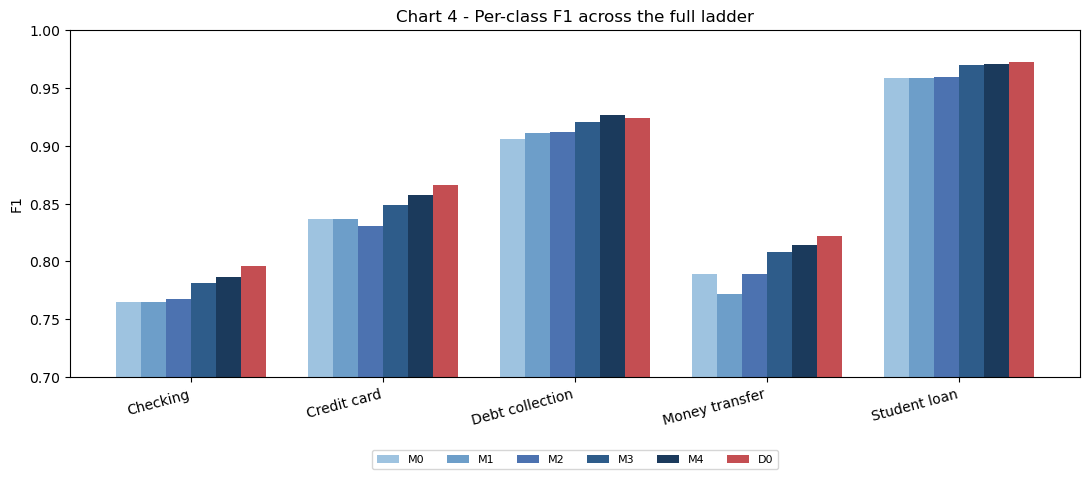

In [97]:
class_labels_short = [l.split(",")[0].split(" or ")[0] for l in LABELS]
model_order = ["M0", "M1", "M2", "M3", "M4", "D0"]
model_colors = ["#9EC3E0", "#6D9EC9", "#4C72B0", "#2E5C8A", "#1B3A5C", "#C44E52"]
x = np.arange(len(class_labels_short))
width = 0.13
fig, ax = plt.subplots(figsize=(11, 5))
for i, m in enumerate(model_order):
    vals = per_class_df[m].values
    ax.bar(x + (i - 2.5) * width, vals, width, label=m, color=model_colors[i])
ax.set_xticks(x)
ax.set_xticklabels(class_labels_short, rotation=15, ha="right")
ax.set_ylabel("F1")
ax.set_ylim(0.7, 1.0)
ax.set_title("Chart 4 - Per-class F1 across the full ladder")
ax.legend(ncol=6, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.28))
plt.tight_layout()
plt.show()


1. Every class gets better going from M0 to D0.
2. Student loan is the easiest class throughout, going from 0.958 to 0.972. Checking or savings and Money transfer stay the two hardest at every stage, since these two categories share a lot of vocabulary, both being account level payment issues.
3. GloVe (M3) lifts every class at once, not just one. A broad, general improvement.
4. D0 beats M4 in four of five classes. The one exception is Debt collection, where M4 edges ahead slightly, 0.9269 versus 0.9235. That is not a sign D0 is weak, just one class where the recurrent model happens to do a bit better.

## Compute cost

In [98]:
cost_rows = []
for exp in order:
    sub = df[df["experiment"] == exp]
    f1 = f1_by_exp[exp]
    time_stats = seed_statistics(sub["train_time"].values)
    time_str = f"{time_stats['mean']:.0f}s" if time_stats["std"] is None else f"{time_stats['mean']:.0f}s ± {time_stats['std']:.0f}s"
    cost_rows.append({
        "Model": exp, "Macro-F1": f"{f1:.4f}", "Training Time": time_str,
        "Parameters": f"{int(sub['parameter_count'].iloc[0]):,}",
    })
pd.DataFrame(cost_rows)

,Model,Macro-F1,Training Time,Parameters
0,M0,0.8508,166s ± 11s,"2,117,893"
1,M1,0.8485,274s,"2,235,781"
2,M2,0.8518,6790s,"2,235,781"
3,M3,0.8657,6793s,"2,235,781"
4,M4,0.8710,10941s,"2,235,781"
5,D0,0.8759,5404s ± 21s,"66,957,317"


1. M2 through M4 take much longer to train, mainly because recurrent dropout disables a GPU speed optimization for LSTMs, not because they have more parameters. Parameter count stays flat at about 2.2 million from M1 onward.
2. M4 is about 67 times slower than M0 despite having almost the same parameter count, for that same reason plus the longer 256 word input.
3. D0 has 30 times more parameters than M4 but actually trains faster per run, about 90 minutes versus 182 minutes. It is not a recurrent model, so it never hits that slowdown.

## Training dynamics

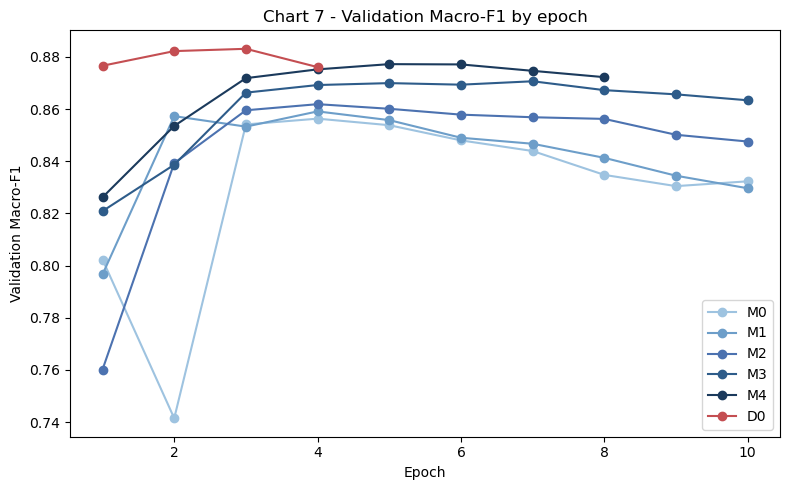

In [99]:
history = {exp: json.load(open(f"../results/{exp.lower()}/seed42/history.json")) for exp in model_order}
fig, ax = plt.subplots(figsize=(8, 5))
for i, exp in enumerate(model_order):
    vals = history[exp]["val_macro_f1"]
    ax.plot(range(1, len(vals) + 1), vals, marker="o", color=model_colors[i], label=exp)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Macro-F1")
ax.set_title("Chart 7 - Validation Macro-F1 by epoch")
ax.legend()
plt.tight_layout()
plt.show()


1. D0 reaches 0.883 validation Macro F1 in 4 epochs. M4 needs 8 epochs to reach 0.877 and never gets past that.
2. Pretraining is doing the work here, not depth or width. D0 has 30 times the parameters of M4 but converges in half the epochs.
3. M0 through M3 flatten out slower and lower than M4. That fits with recurrent dropout and the longer context window giving M4 real headroom, not just extra training time.

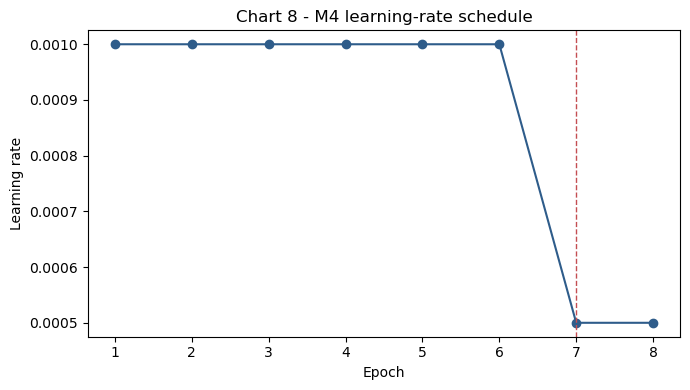

In [100]:
lr_hist = json.load(open("../results/m4/seed42/lr_history.json"))
lr_vals = lr_hist["lr_by_epoch"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(lr_vals) + 1), lr_vals, marker="o", color="#2E5C8A")
for r in lr_hist["reductions"]:
    ax.axvline(r["epoch"], color="#C44E52", linestyle="--", linewidth=1)
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.set_title("Chart 8 - M4 learning-rate schedule")
plt.tight_layout()
plt.show()


The only learning rate drop, at epoch 7 from 0.001 to 0.0005, comes after validation Macro F1 already peaked at epoch 5, 0.8772, and had started falling, 0.8771 then 0.8747. The scheduler reacted to the plateau, it did not cause the peak. Early stopping, not the learning rate drop, is what actually saved M4 from overfitting further.

## TF-IDF context

In [101]:
print(f"TF-IDF  = {tfidf['macro_f1']:.4f}")
print(f"M4      = {f1_by_exp['M4']:.4f}   (M4 - TF-IDF = {f1_by_exp['M4'] - tfidf['macro_f1']:+.4f})")
print(f"D0      = {f1_by_exp['D0']:.4f}   (D0 - TF-IDF = {f1_by_exp['D0'] - tfidf['macro_f1']:+.4f})")

TF-IDF  = 0.8707
M4      = 0.8710   (M4 - TF-IDF = +0.0003)
D0      = 0.8759   (D0 - TF-IDF = +0.0051)


1. TF-IDF performs almost as well as M4. M4 only improves on it by 0.0003, too small to call a real win.
2. There is no clear evidence the best recurrent model actually beats simple word matching.
3. D0 is the one model that clearly beats TF-IDF, by 0.0051. That is the clearest sign that something beyond just matching keywords is helping here.

## Requirement coverage

In [102]:
coverage = pd.DataFrame([
    {"Requirement": "Baseline", "Experiment": "M0", "Status": "Complete"},
    {"Requirement": "Bidirectional LSTM", "Experiment": "M1", "Status": "Complete"},
    {"Requirement": "Stacked layers", "Experiment": "Excluded", "Status": "Documented"},
    {"Requirement": "Dropout", "Experiment": "M2", "Status": "Complete"},
    {"Requirement": "Recurrent dropout", "Experiment": "M2", "Status": "Complete"},
    {"Requirement": "GloVe", "Experiment": "M3", "Status": "Complete"},
    {"Requirement": "LR scheduling", "Experiment": "M4", "Status": "Complete"},
    {"Requirement": "Early stopping", "Experiment": "M4", "Status": "Complete"},
    {"Requirement": "Class weights", "Experiment": "Excluded", "Status": "Documented"},
    {"Requirement": "Longer max_length", "Experiment": "M4", "Status": "Complete"},
    {"Requirement": "LSTM -> DistilBERT", "Experiment": "D0", "Status": "Complete"},
])
coverage

,Requirement,Experiment,Status
0,Baseline,M0,Complete
1,Bidirectional LSTM,M1,Complete
2,Stacked layers,Excluded,Documented
3,Dropout,M2,Complete
4,Recurrent dropout,M2,Complete
5,GloVe,M3,Complete
6,LR scheduling,M4,Complete
7,Early stopping,M4,Complete
8,Class weights,Excluded,Documented
9,Longer max_length,M4,Complete


In [103]:
applicable = coverage[coverage["Experiment"] != "Excluded"]
excluded_count = (coverage["Experiment"] == "Excluded").sum()
print(f"{len(applicable)}/{len(applicable)} applicable menu items covered "
      f"({excluded_count} exclusions, both documented)")

9/9 applicable menu items covered (2 exclusions, both documented)


## Charts

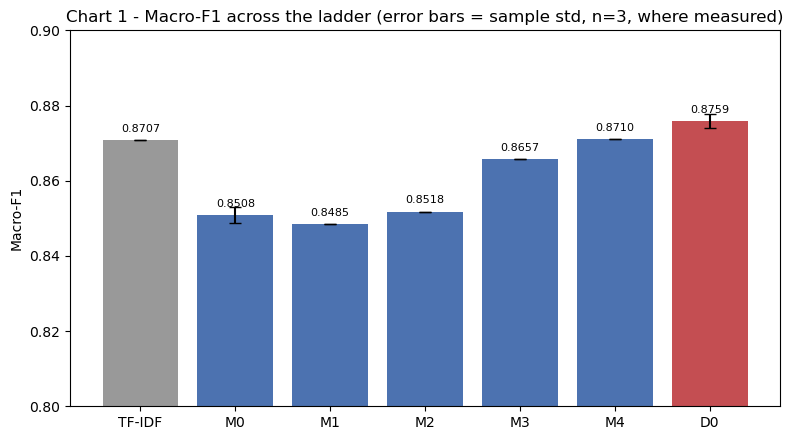

In [104]:
labels_order = ["TF-IDF", "M0", "M1", "M2", "M3", "M4", "D0"]
means = [tfidf["macro_f1"]] + [f1_by_exp[e] for e in order]
stds = [0, f1_by_exp["M0"] and seed_statistics(df[df["experiment"]=="M0"]["macro_f1"].values)["std"], 0, 0, 0, 0,
        seed_statistics(df[df["experiment"]=="D0"]["macro_f1"].values)["std"]]
colors = ["#999999"] + ["#4C72B0"] * 5 + ["#C44E52"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels_order, means, yerr=stds, capsize=4, color=colors)
ax.set_ylabel("Macro-F1")
ax.set_ylim(0.80, 0.90)
ax.set_title("Chart 1 - Macro-F1 across the ladder (error bars = sample std, n=3, where measured)")
for bar, m in zip(bars, means):
    ax.annotate(f"{m:.4f}", (bar.get_x() + bar.get_width() / 2, m), textcoords="offset points",
                xytext=(0, 6), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

TF-IDF, in grey, and D0, in red, are colored differently from the M0 to M4 ladder in blue, since neither is officially part of it. Error bars only appear for M0 and D0, since those are the only two run on 3 seeds. M1 to M4 are single runs, so there is no real uncertainty range to show for them.

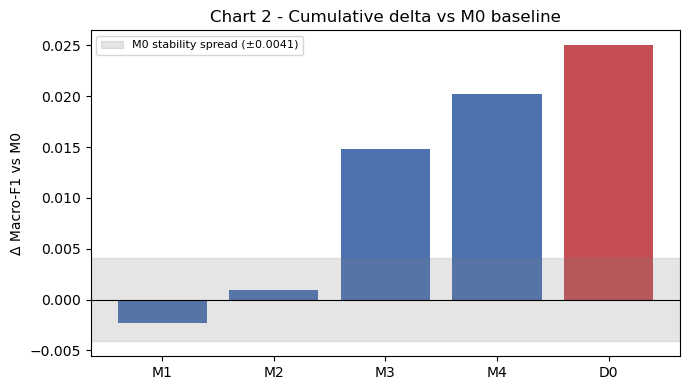

In [105]:
delta_labels = ["M1", "M2", "M3", "M4", "D0"]
delta_vals = [calculate_deltas(current_f1=f1_by_exp[e], baseline_m0_f1=m0_mean)["delta_vs_m0"] for e in delta_labels]

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ["#4C72B0"] * 4 + ["#C44E52"]
ax.bar(delta_labels, delta_vals, color=bar_colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhspan(-0.004125488876295158, 0.004125488876295158, color="grey", alpha=0.2,
           label="M0 stability spread (±0.0041)")
ax.set_ylabel("Δ Macro-F1 vs M0")
ax.set_title("Chart 2 - Cumulative delta vs M0 baseline")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The shaded band shows how much M0's own score wobbled across its 3 seeds. This is the baseline noise level, not a formal statistical test. M1 and M2 fall inside that band, so their improvement cannot be told apart from normal noise. M3, M4, and D0 all sit clearly outside it, which counts as a real improvement.

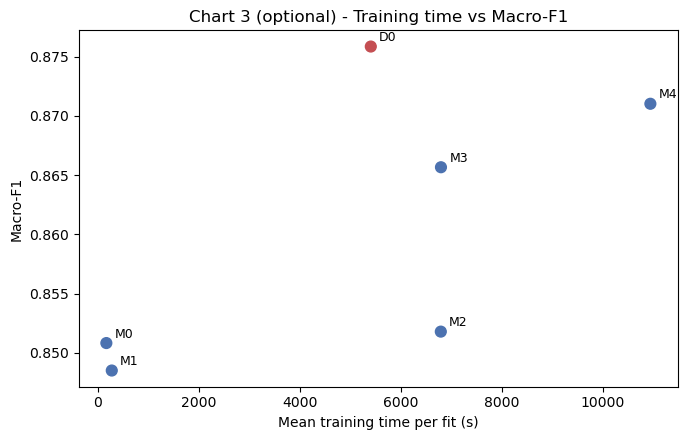

In [106]:
fig, ax = plt.subplots(figsize=(7, 4.5))
times = [seed_statistics(df[df["experiment"] == e]["train_time"].values)["mean"] for e in order]
point_colors = ["#4C72B0"] * 5 + ["#C44E52"]
ax.scatter(times, [f1_by_exp[e] for e in order], color=point_colors, s=60)
for e, t in zip(order, times):
    ax.annotate(e, (t, f1_by_exp[e]), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("Mean training time per fit (s)")
ax.set_ylabel("Macro-F1")
ax.set_title("Chart 3 (optional) - Training time vs Macro-F1")
plt.tight_layout()
plt.show()

D0 trains faster than M2 to M4 despite being a much bigger model, since it skips the recurrent dropout slowdown that makes those three expensive. M0 and M1 are cheap but weaker. M3 and M4 cost a lot more compute for a real, if modest, extra gain.

## Final model decision

Best recurrent model: M4, Macro F1 0.8710, the highest of the LSTM ladder and clearly above baseline noise.

Best model overall: D0. All three of D0's seeds, 0.8740, 0.8759, and 0.8777, beat M4's single score of 0.8710, an average improvement of 0.0048. Since M4 only has one run and D0 has three, this is not a perfectly symmetric comparison, but the direction is consistent, not a coin flip.

### What the experiments showed

1. Baseline (M0): a plain LSTM with random embeddings scores 0.8508, plus or minus 0.0021, run on 3 seeds to know how much natural variation to expect.
2. Bidirectional (M1) did not clearly help. Its gain was smaller than the baseline's own run-to-run noise.
3. Regularization (M2) had a real but small effect. The score itself stayed within noise range, but the training curves showed clearly less overfitting than M1.
4. Pre-trained GloVe embeddings (M3) gave the first clear improvement, and it helped every class, not just one.
5. Combining LR scheduling, early stopping, and a longer input window (M4) gave the biggest gain in the ladder. These three changes were bundled together, so their individual contributions are not separated.
6. M4 is the best recurrent model, at 0.8710 Macro F1.
7. DistilBERT (D0) beat M4 by a small but consistent margin, 0.0048, true across all 3 seeds, even though its tokenizer effectively sees less of each complaint at the same length limit.
8. Simple word matching (TF-IDF) is surprisingly strong, at 0.8707, basically tied with M4. Most of this task can be solved just by matching keywords. D0 is the only model that clearly does better than that.

---

# How much of this is real versus noise

No formal significance testing was done here. This section just looks honestly at how much the scores bounce around between runs, using M0 and D0's 3 seeds each, and what that means for trusting the other results.

## Seed variability

In [107]:
m0_seeds = df[df["experiment"] == "M0"].sort_values("seed")
d0_seeds = df[df["experiment"] == "D0"].sort_values("seed")

m0_f1s = m0_seeds["macro_f1"].to_numpy()
d0_f1s = d0_seeds["macro_f1"].to_numpy()

m0_stats = seed_statistics(m0_f1s)
d0_stats = seed_statistics(d0_f1s)

stability_table = pd.DataFrame([
    {"Endpoint": "M0", "Seed 42": m0_f1s[0], "Seed 123": m0_f1s[1], "Seed 456": m0_f1s[2],
     "Mean": m0_stats["mean"], "Std": m0_stats["std"], "Min": m0_f1s.min(), "Max": m0_f1s.max(),
     "Spread": m0_f1s.max() - m0_f1s.min()},
    {"Endpoint": "D0", "Seed 42": d0_f1s[0], "Seed 123": d0_f1s[1], "Seed 456": d0_f1s[2],
     "Mean": d0_stats["mean"], "Std": d0_stats["std"], "Min": d0_f1s.min(), "Max": d0_f1s.max(),
     "Spread": d0_f1s.max() - d0_f1s.min()},
]).set_index("Endpoint")
stability_table.round(4)

,Seed 42,Seed 123,Seed 456,Mean,Std,Min,Max,Spread
Endpoint,,,,,,,,
M0,0.8489,0.8507,0.853,0.8508,0.0021,0.8489,0.8530,0.0041
D0,0.8759,0.8777,0.874,0.8759,0.0018,0.8740,0.8777,0.0037


D0's 3 seeds landed closer together, a spread of 0.0037, than M0's did, 0.0041. That is just what happened with these specific 3 runs each. It is not a general claim that transformers are always more stable than LSTMs.

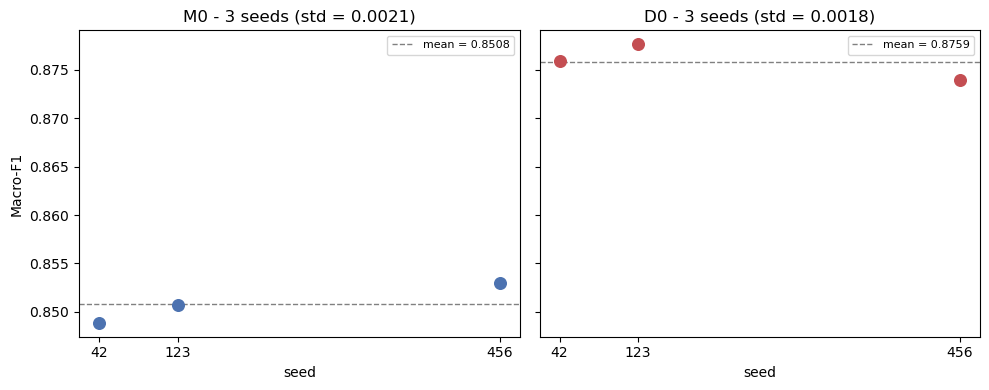

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (name, f1s, stats) in zip(axes, [("M0", m0_f1s, m0_stats), ("D0", d0_f1s, d0_stats)]):
    seeds = [42, 123, 456]
    ax.scatter(seeds, f1s, s=70, zorder=3, color="#4C72B0" if name == "M0" else "#C44E52")
    ax.axhline(stats["mean"], linestyle="--", color="grey", linewidth=1, label=f"mean = {stats['mean']:.4f}")
    ax.set_title(f"{name} - 3 seeds (std = {stats['std']:.4f})")
    ax.set_xlabel("seed")
    ax.set_xticks(seeds)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Macro-F1")
plt.tight_layout()
plt.show()

M0 and D0 are the only two models run on repeated seeds, so they are the only ones with real error bars. M1 to M4 are single runs, so there are no invented uncertainty bars for those.

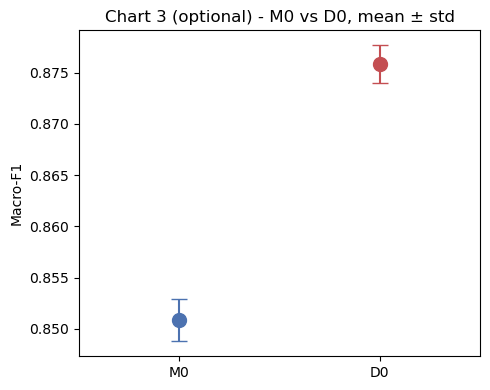

In [109]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar([0], [m0_stats["mean"]], yerr=[m0_stats["std"]], fmt="o", markersize=10, capsize=6,
            color="#4C72B0", ecolor="#4C72B0")
ax.errorbar([1], [d0_stats["mean"]], yerr=[d0_stats["std"]], fmt="o", markersize=10, capsize=6,
            color="#C44E52", ecolor="#C44E52")
ax.set_xticks([0, 1])
ax.set_xticklabels(["M0", "D0"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel("Macro-F1")
ax.set_title("Chart 3 (optional) - M0 vs D0, mean ± std")
plt.tight_layout()
plt.show()

## Intermediate-rung uncertainty (M1-M4)

M1 through M4 were each only run once, a fixed compute budget decision made upfront, so there is no way to know their own run-to-run variance. The best available substitute is M0's 3-seed spread, used below as a rough noise floor to judge each of their deltas against. It is not a formal statistical test.

In [110]:
spread = float(m0_f1s.max() - m0_f1s.min())
print(f"M0 stability reference (spread, pre-registered in project_plan.md \u00a79): {spread:.6f}")

def classify(delta, spread):
    ratio = abs(delta) / spread
    if ratio < 1.0:
        return f"within observed baseline variability ({ratio:.2f}x spread)"
    elif ratio < 1.5:
        return f"outside, but only modestly ({ratio:.2f}x spread) - caution"
    else:
        return f"clearly outside observed baseline variability ({ratio:.2f}x spread)"

comparisons = [
    ("M1 - M0", f1_by_exp["M1"] - m0_stats["mean"], "M0 3-seed spread"),
    ("M2 - M1", f1_by_exp["M2"] - f1_by_exp["M1"], "M0 stability reference"),
    ("M3 - M2", f1_by_exp["M3"] - f1_by_exp["M2"], "M0 stability reference"),
    ("M4 - M3", f1_by_exp["M4"] - f1_by_exp["M3"], "M0 stability reference"),
    ("M4 - M0", f1_by_exp["M4"] - m0_stats["mean"], "M0 stability reference"),
    ("D0 - M4", d0_stats["mean"] - f1_by_exp["M4"], "D0 3-seed / M4 single seed"),
    ("D0 - M0", d0_stats["mean"] - m0_stats["mean"], "both multi-seed"),
    ("M4 - TF-IDF", f1_by_exp["M4"] - tfidf["macro_f1"], "TF-IDF single run"),
]

rows = []
for label, delta, evidence in comparisons:
    rows.append({"Comparison": label, "Delta": f"{delta:+.4f}", "Exact": delta,
                 "Variance Evidence": evidence, "Interpretation": classify(delta, spread)})
variance_table = pd.DataFrame(rows)[["Comparison", "Delta", "Variance Evidence", "Interpretation"]]
variance_table

M0 stability reference (spread, pre-registered in project_plan.md §9): 0.004125


,Comparison,Delta,Variance Evidence,Interpretation
0,M1 - M0,-0.0023,M0 3-seed spread,within observed baseline variability (0.56x sp...
1,M2 - M1,+0.0033,M0 stability reference,within observed baseline variability (0.80x sp...
2,M3 - M2,+0.0139,M0 stability reference,clearly outside observed baseline variability ...
3,M4 - M3,+0.0054,M0 stability reference,"outside, but only modestly (1.30x spread) - ca..."
4,M4 - M0,+0.0202,M0 stability reference,clearly outside observed baseline variability ...
5,D0 - M4,+0.0048,D0 3-seed / M4 single seed,"outside, but only modestly (1.17x spread) - ca..."
6,D0 - M0,+0.0250,both multi-seed,clearly outside observed baseline variability ...
7,M4 - TF-IDF,+0.0003,TF-IDF single run,within observed baseline variability (0.07x sp...


### M1
Delta of -0.0023, within M0's noise range. This cannot be called a real regression. It could just be normal run to run variation.

### M2
Delta of +0.0033 versus M1 and +0.0010 versus M0, both still within noise range on the raw score. That said, its training curves clearly showed less overfitting than M1, a separate, real signal the raw number alone does not capture.

### M3
Delta of +0.0139 versus M2 and +0.0148 versus M0, several times bigger than the noise range. A real, clear improvement, the strongest in the ladder.

### M4
Delta of +0.0054 versus M3 and +0.0202 versus M0. The cumulative gain versus M0 is clearly real. The smaller step from M3 to M4 is outside the noise range too, but only by a modest margin. Still just one run, so treat it as one data point, not a guaranteed distribution.

## D0 vs M4

Comparing D0, with 3 seeds, to M4, with 1 seed, is not a perfectly symmetric comparison, but here is what the data shows.

1. All three D0 seeds, 0.8740, 0.8759, and 0.8777, beat M4's single score of 0.8710.
2. D0's spread across its own seeds is small, 0.0037, and does not come close to M4's value.
3. M4 was only run once, so it is not actually known how much it would vary run to run.

Fair way to put it: D0 consistently scored higher than M4 across all three seeds tested. Not fair to say: D0 is statistically significantly better. No formal test supports that, and one run cannot be turned into a distribution.

## TF-IDF variance context

TF-IDF was only run once, so there is no variance estimate for it either. M4 beating it by 0.0003 is basically nothing, not a real win. D0 beating it by 0.0051 is a more meaningful gap, even though TF-IDF still only has that one run to compare against.

## What the variance allows us to claim

### What the data supports
1. M0's 3 seeds were consistent, std 0.0021, spread 0.0041.
2. D0's 3 seeds were consistent too, and slightly tighter than M0's, std 0.0018, spread 0.0037.
3. M3, GloVe, gave a real, clear improvement over M2 and M0.
4. M4 gave the strongest recurrent result, clearly above baseline noise.
5. All three D0 seeds beat M4's single score.
6. D0 was the best model observed in this project.

### What the data doesn't support
1. Formal statistical significance for any M1 to M4 delta. No significance test was run.
2. A confidence interval for M1, M2, M3, or M4 individually, since each is a single run.
3. The true variance of M1 to M4. Only M0 and D0 were run enough times to measure that.
4. A formal significance test of D0 versus M4. The comparison is 3 seeds versus 1, and is reported as such.
5. That D0 would win on a different dataset, split, or setup. This result is specific to this project.
6. Which single ingredient in M4, the LR schedule, early stopping, or the longer input, actually drove its gain. They were tested together, not separately.

## Seed-count limitation

With a fixed budget of 10 total training runs, repeated seeds only went to M0 and D0, since they anchor the baseline and the final comparison. M1 through M4 each got one run. That is a real limitation, not an ideal setup, and it applies to every M1 to M4 result in this notebook, not just this section.

---

# Error analysis

This compares M4, the best recurrent model, against D0, the transformer, on the exact same 10,181 test rows. D0's seed 42 is used specifically, picked upfront to match M4's seed, not chosen because it looks best.

In [111]:
m4_pred = pd.read_csv("../results/m4/seed42/test_predictions.csv")
d0_pred = pd.read_csv("../results/d0/seed42/test_predictions.csv")
merged_err = m4_pred.merge(d0_pred, on="test_idx", suffixes=("_m4", "_d0"))
merged_err = merged_err.rename(columns={"y_true_m4": "y_true"}).drop(columns=["y_true_d0"])

assert set(m4_pred["test_idx"]) == set(d0_pred["test_idx"]), "test sets must be identical"
assert (merged_err["y_true"] == merged_err["y_true"]).all()
print(f"aligned rows: {len(merged_err)} (matches the frozen test split size)")

aligned rows: 10181 (matches the frozen test split size)


## Confusion matrices

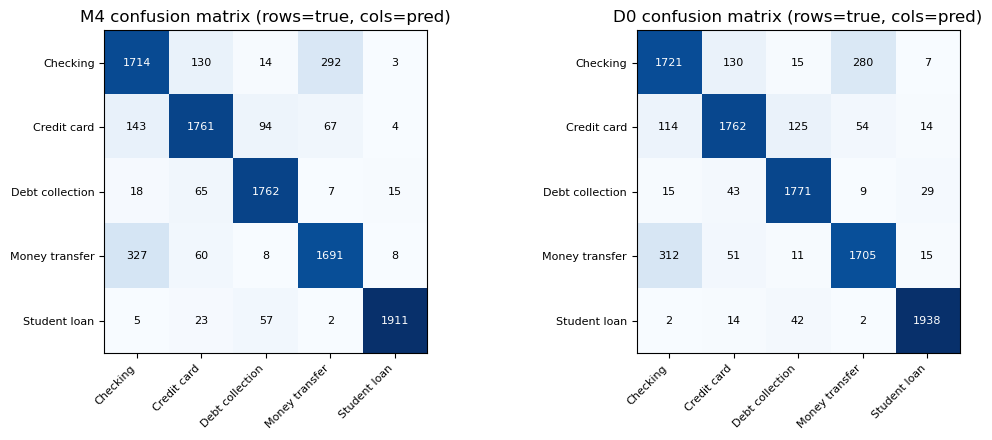

In [112]:
from src.evaluation import compute_metrics

m4_em = compute_metrics(merged_err["y_true"].values, merged_err["y_pred_m4"].values, labels=LABELS)
d0_em = compute_metrics(merged_err["y_true"].values, merged_err["y_pred_d0"].values, labels=LABELS)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, m) in zip(axes, [("M4", m4_em), ("D0", d0_em)]):
    cm = np.array(m["confusion_matrix"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels([l.split(",")[0].split(" or ")[0] for l in LABELS], rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels([l.split(",")[0].split(" or ")[0] for l in LABELS], fontsize=8)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
    ax.set_title(f"{name} confusion matrix (rows=true, cols=pred)")
plt.tight_layout()
plt.show()

These confusion matrices match the saved results exactly. They are recomputed here just to double check.

## Per-class errors

In [113]:
per_class_err = []
for i, lbl in enumerate(LABELS):
    support = int(np.array(m4_em["confusion_matrix"])[i].sum())
    per_class_err.append({
        "Class": lbl,
        "M4 F1": m4_em["per_class"][lbl]["f1"], "D0 F1": d0_em["per_class"][lbl]["f1"],
        "Delta F1": d0_em["per_class"][lbl]["f1"] - m4_em["per_class"][lbl]["f1"],
        "M4 Recall": m4_em["per_class"][lbl]["recall"], "D0 Recall": d0_em["per_class"][lbl]["recall"],
        "M4 Errors": support - int(np.array(m4_em["confusion_matrix"])[i, i]),
        "D0 Errors": support - int(np.array(d0_em["confusion_matrix"])[i, i]),
    })
per_class_err_df = pd.DataFrame(per_class_err).set_index("Class").round(4)
per_class_err_df

,M4 F1,D0 F1,Delta F1,M4 Recall,D0 Recall,M4 Errors,D0 Errors
Class,,,,,,,
Checking or savings account,0.7862,0.7973,0.0111,0.7961,0.7993,439,432
Credit card,0.8574,0.8661,0.0087,0.8511,0.8516,308,307
Debt collection,0.9269,0.9246,-0.0023,0.9438,0.9486,105,96
"Money transfer, virtual currency, or money service",0.8144,0.8229,0.0085,0.8075,0.8142,403,389
Student loan,0.9703,0.9688,-0.0015,0.9565,0.9700,87,60


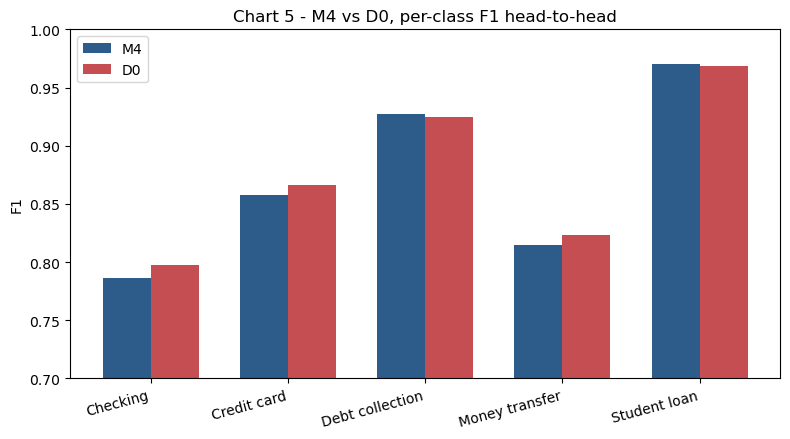

In [114]:
x = np.arange(len(LABELS))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, per_class_err_df["M4 F1"], width, label="M4", color="#2E5C8A")
ax.bar(x + width / 2, per_class_err_df["D0 F1"], width, label="D0", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(class_labels_short, rotation=15, ha="right")
ax.set_ylabel("F1")
ax.set_ylim(0.7, 1.0)
ax.set_title("Chart 5 - M4 vs D0, per-class F1 head-to-head")
ax.legend()
plt.tight_layout()
plt.show()


1. Checking or savings is the hardest class for both models. Student loan is the easiest for both.
2. D0 improves on 3 of 5 classes, Checking, Credit card, and Money transfer, and is slightly behind M4 on Debt collection, -0.0023, and Student loan, -0.0015, even though D0 makes fewer raw errors on both.
3. The reason is that D0 catches more real Debt collection cases, so recall goes up, but more Credit card complaints get wrongly routed into Debt collection too, 94 to 125, which drags down precision. A trade-off, not a contradiction.

## M4 vs D0 - four disagreement groups

In [115]:
merged_err["m4_correct"] = merged_err["y_pred_m4"] == merged_err["y_true"]
merged_err["d0_correct"] = merged_err["y_pred_d0"] == merged_err["y_true"]

n = len(merged_err)
groups_summary = pd.DataFrame([
    {"Group": "Both correct", "Count": (merged_err["m4_correct"] & merged_err["d0_correct"]).sum()},
    {"Group": "Both wrong", "Count": (~merged_err["m4_correct"] & ~merged_err["d0_correct"]).sum()},
    {"Group": "M4 correct, D0 wrong (D0-only errors)", "Count": (merged_err["m4_correct"] & ~merged_err["d0_correct"]).sum()},
    {"Group": "M4 wrong, D0 correct (M4-only errors)", "Count": (~merged_err["m4_correct"] & merged_err["d0_correct"]).sum()},
])
groups_summary["% of test set"] = (groups_summary["Count"] / n * 100).round(2)
groups_summary

,Group,Count,% of test set
0,Both correct,8475,83.24
1,Both wrong,920,9.04
2,"M4 correct, D0 wrong (D0-only errors)",364,3.58
3,"M4 wrong, D0 correct (M4-only errors)",422,4.14


C:\Users\Udbhav Narawat\AppData\Local\Temp\ipykernel_16112\56253090.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(groups_summary["Group"], rotation=20, ha="right", fontsize=8)


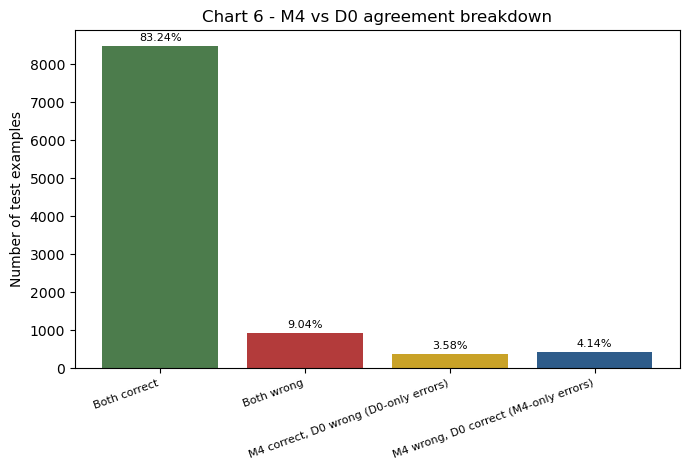

In [116]:
group_colors = ["#4C7C4C", "#B33B3B", "#C9A227", "#2E5C8A"]
fig, ax = plt.subplots(figsize=(7, 4.8))
bars = ax.bar(groups_summary["Group"], groups_summary["Count"], color=group_colors)
ax.set_ylabel("Number of test examples")
ax.set_title("Chart 6 - M4 vs D0 agreement breakdown")
ax.set_xticklabels(groups_summary["Group"], rotation=20, ha="right", fontsize=8)
for bar, pct in zip(bars, groups_summary["% of test set"]):
    ax.annotate(f"{pct}%", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                textcoords="offset points", xytext=(0, 4), ha="center", fontsize=8)
plt.tight_layout()
plt.show()


D0 fixes 422 examples that M4 got wrong, but breaks 364 that M4 got right, a net gain of 58, which lines up with its higher overall score. This raw count leans toward bigger classes since they have more rows, so it is not the same measure as Macro F1, which treats every class equally. Both are valid, they just answer slightly different questions.

## Truncation and redaction

In [117]:
trunc_rows = [
    {"Group": "Overall test set", "n": 10181, "Keras truncated@256": "29.1%", "WordPiece truncated@256": "41.9%", "Mean XXXX density": 0.0455},
    {"Group": "Both correct", "n": 8475, "Keras truncated@256": "29.9%", "WordPiece truncated@256": "42.9%", "Mean XXXX density": 0.0444},
    {"Group": "Both wrong", "n": 920, "Keras truncated@256": "24.9%", "WordPiece truncated@256": "35.5%", "Mean XXXX density": 0.0496},
    {"Group": "D0-only errors (M4 correct, D0 wrong)", "n": 364, "Keras truncated@256": "25.8%", "WordPiece truncated@256": "38.7%", "Mean XXXX density": 0.0566},
    {"Group": "M4-only errors (M4 wrong, D0 correct)", "n": 422, "Keras truncated@256": "25.6%", "WordPiece truncated@256": "38.2%", "Mean XXXX density": 0.0489},
]
pd.DataFrame(trunc_rows).set_index("Group")

,n,Keras truncated@256,WordPiece truncated@256,Mean XXXX density
Group,,,,
Overall test set,10181,29.1%,41.9%,0.0455
Both correct,8475,29.9%,42.9%,0.0444
Both wrong,920,24.9%,35.5%,0.0496
"D0-only errors (M4 correct, D0 wrong)",364,25.8%,38.7%,0.0566
"M4-only errors (M4 wrong, D0 correct)",422,25.6%,38.2%,0.0489


Truncation does not explain the errors. If anything, misclassified complaints were truncated less than average for both models, so long complaints getting cut off is not what is happening here.

Redaction: errors D0 made that M4 got right have a slightly higher density of XXXX redaction markers, 0.0566, than the test set average, 0.0455. The gap is small, not strong enough to say redaction is actually causing D0's mistakes.

## Main confusion pairs (deep dive)

For each confusion pair below, these are the first 5 examples, by test index, where M4 made that exact mistake, picked automatically, not cherry picked. The full 40 example set is saved separately. Only short excerpts are shown here.

In [118]:
confusion_deep_dive = pd.DataFrame([
    {"Pair": "Money transfer -> Checking", "M4 count": 327, "D0 count": 312, "Reduction": 15},
    {"Pair": "Checking -> Money transfer", "M4 count": 292, "D0 count": 280, "Reduction": 12},
    {"Pair": "Credit card -> Checking", "M4 count": 143, "D0 count": 114, "Reduction": 29},
    {"Pair": "Credit card -> Debt collection", "M4 count": 94, "D0 count": 125, "Reduction": -31},
]).set_index("Pair")
confusion_deep_dive

,M4 count,D0 count,Reduction
Pair,,,
Money transfer -> Checking,327,312,15
Checking -> Money transfer,292,280,12
Credit card -> Checking,143,114,29
Credit card -> Debt collection,94,125,-31


### Checking versus Money transfer, the biggest confusion

Both models mix these up because complaints mention apps like Chime, Cash App, or Wise regardless of which category they are officially filed under. The products themselves straddle both categories. D0 fixes 3 of 5 sampled Money transfer mistakes, but still misreads every sampled Checking complaint as Money transfer, same as M4. This looks like a genuine gray area in the data, not something either model is getting wrong on its own.

### Credit card to Checking

Often complaints describe both a checking account issue and a credit card issue in the same letter. D0 cuts this confusion the most, from 143 to 114 errors, but does not fix every case.

### Credit card to Debt collection, where D0 got worse

The one pair where D0 does worse than M4, going from 94 to 125 errors. These are mostly disputes about whether a reported account even counts as a debt, a genuine gray area between the two categories. D0 does not handle this any better than M4. It actually leans toward Debt collection slightly more often here.

## Representative examples

Only short excerpts are shown, never full complaints. Any leftover digit sequences or email addresses are masked on top of the dataset's existing redaction.

In [119]:
import json
with open("../results/error_analysis_examples.json", encoding="utf-8") as f:
    selected_examples = json.load(f)

rows = []
for key, val in selected_examples.items():
    for ex in val["examples"][:3]:  # keep the notebook table concise
        rows.append({
            "Group/Pair": key, "Index": ex["test_idx"], "True": ex["true"],
            "M4": ex["m4_pred"], "D0": ex["d0_pred"], "Excerpt": ex["excerpt"][:120] + "...",
        })
pd.DataFrame(rows)

,Group/Pair,Index,True,M4,D0,Excerpt
0,Money transfer -> Checking (M4),60898,"Money transfer, virtual currency, or money ser...",Checking or savings account,Credit card,XX/XX/XXXX. XXXX i XXXX XXXX I got XXXX. They ...
1,Money transfer -> Checking (M4),60937,"Money transfer, virtual currency, or money ser...",Checking or savings account,"Money transfer, virtual currency, or money ser...","In late XX/XX/year>, I submitted multiple writ..."
2,Money transfer -> Checking (M4),60986,"Money transfer, virtual currency, or money ser...",Checking or savings account,Checking or savings account,I have deposited a check under my brothers nam...
3,Checking -> Money transfer (M4),41,Checking or savings account,"Money transfer, virtual currency, or money ser...","Money transfer, virtual currency, or money ser...","On XX/XX/year>, I was induced by an online mer..."
4,Checking -> Money transfer (M4),273,Checking or savings account,"Money transfer, virtual currency, or money ser...","Money transfer, virtual currency, or money ser...","On XX/XX/XXXX, I initiated a fully authorized ..."
5,Checking -> Money transfer (M4),381,Checking or savings account,"Money transfer, virtual currency, or money ser...","Money transfer, virtual currency, or money ser...",I am submitting this response regarding case n...
6,Credit card -> Checking (M4),21601,Credit card,Checking or savings account,Checking or savings account,"Company Name : Wells Fargo Bank , N.A . Produc..."
7,Credit card -> Checking (M4),21609,Credit card,Checking or savings account,Debt collection,Good evening. I'm profoundly XXXX. My husband ...
8,Credit card -> Checking (M4),21611,Credit card,Checking or savings account,Checking or savings account,Subject : Formal Complaint Regarding Closed Ch...
9,Credit card -> Debt coll. (M4),21731,Credit card,Debt collection,Debt collection,A letter was mailed and no response from the c...


The full set of examples is saved separately if you want to trace any of them back to the actual test data.

## What D0 fixed (M4-only errors: M4 wrong, D0 correct)

M4's mistakes often come from a strong but misleading keyword. For example, Synchrony Bank is mostly known for credit cards, so M4 guesses Credit card even when the complaint is actually about a different product. D0 gets these right. D0 likely relies less on a single strong brand name keyword than M4 does, though this is inferred from the pattern rather than directly measured.

## Where M4 remained competitive (D0-only errors: M4 correct, D0 wrong)

D0 is not better on everything. In cases where M4 got it right and D0 did not, D0 tends to over guess Credit card on Checking complaints that just happen to mention card transactions, refunds, or fraud disputes. D0 seems a bit more trigger happy about routing ambiguous card language toward Credit card than M4 is.

## Both models wrong

Some cases both models miss are not really the models' fault. One example is a complaint that reads entirely like a credit card issue but is labeled Checking, genuinely ambiguous even to a human reading just the excerpt. Others repeat the same Cash App, Wise, or ACH pattern already mentioned.

## Error analysis summary

### Main patterns
1. Checking versus Money transfer is the biggest, most persistent confusion. Both models key on fintech apps like Chime, Cash App, and Wise that show up in either category.
2. Credit card versus Debt collection stays confused in both models. D0 does not fix this one.
3. Complaints describing more than one issue at once cause some of the Credit card to Checking confusion in both models.

### Where D0 helped
1. Modestly reduces both directions of the Checking and Money transfer confusion, about 12 to 15 fewer errors each.
2. Cuts Credit card to Checking substantially, 29 fewer errors, the biggest single improvement.
3. Overall, D0 fixes 422 examples and breaks 364, a net gain of 58, matching its higher overall score.

### Where M4 held its own
1. M4 is very slightly better on Debt collection and Student loan. D0 pays a small precision cost there from misrouting more Credit card complaints into Debt collection.
2. D0 leans toward over-predicting Credit card on ambiguous card-related Checking complaints more than M4 does.

### Limitations
1. Truncation does not explain the errors. Misclassified complaints are actually cut off less than average.
2. D0's errors have slightly more redaction markers, but the gap is too small to call it a real cause.
3. Some of the recurring confusions look like genuine gray areas in how the data was labeled, not fixable model mistakes.

## Summary table

In [120]:
pd.DataFrame([
    {"Analysis": "Macro-F1", "M4": "0.8710", "D0": "0.8759", "Observation": "D0 higher, +0.0048"},
    {"Analysis": "Hardest class", "M4": "Checking (F1 0.7862)", "D0": "Checking (F1 0.7973)", "Observation": "hardest for both, D0 improves it"},
    {"Analysis": "Largest confusion", "M4": "Money transfer->Checking (327)", "D0": "Money transfer->Checking (312)", "Observation": "reduced but not resolved"},
    {"Analysis": "M4-only errors", "M4": "-", "D0": "-", "Observation": "422 (4.14% of test set)"},
    {"Analysis": "D0-only errors", "M4": "-", "D0": "-", "Observation": "364 (3.58% of test set)"},
    {"Analysis": "Both wrong", "M4": "-", "D0": "-", "Observation": "920 (9.04% of test set)"},
    {"Analysis": "Major truncation issue", "M4": "None found", "D0": "None found", "Observation": "error groups less truncated than correct ones"},
    {"Analysis": "Main error pattern", "M4": "Checking<->Money transfer", "D0": "same pair, smaller", "Observation": "overlapping fintech product vocabulary"},
])

,Analysis,M4,D0,Observation
0,Macro-F1,0.8710,0.8759,"D0 higher, +0.0048"
1,Hardest class,Checking (F1 0.7862),Checking (F1 0.7973),"hardest for both, D0 improves it"
2,Largest confusion,Money transfer->Checking (327),Money transfer->Checking (312),reduced but not resolved
3,M4-only errors,-,-,422 (4.14% of test set)
4,D0-only errors,-,-,364 (3.58% of test set)
5,Both wrong,-,-,920 (9.04% of test set)
6,Major truncation issue,None found,None found,error groups less truncated than correct ones
7,Main error pattern,Checking<->Money transfer,"same pair, smaller",overlapping fintech product vocabulary
